In [591]:
import pandas as pd
from sodapy import Socrata
import numpy as np
import plotly.express as px
import yfinance as yf
import requests
import zipfile
import plotly.graph_objects as go

Phase 1 — Complete current work (nearly done)
+ ✓ SP500 three actor analysis
+ ✓ Robustness tests
+ → Add non-reportables
+ → Run same analysis on 10Y Treasury and VIX
+ add ETF FLow Data
+ Use price-implied positioning

Phase 2 — Cross asset positioning matrix
+ → Build unified positioning dataset across 6 instruments
+ → Compute cross-asset positioning divergence scores
+ → Test whether bond positioning predicts equity returns
+ → Test whether VIX positioning predicts equity returns

Phase 3 — Full container model
+ → Map capital flow proxies across asset classes
+ → Build rolling flow score per asset
+ → Test whether flow exhaustion in one predicts inflow to another
+ → This is the original theory fully realised

# Maps

In [ ]:
INSTRUMENT_MAP = {
    # S&P 500 — all variants map to same instrument
    "ADJUSTED INT RATE S&P 500 TOTL - CHICAGO MERCANTILE EXCHANGE" :    "SP500",
    "E-MINI S&P 500 - CHICAGO MERCANTILE EXCHANGE" :                    "SP500",
    "E-MINI S&P 500 STOCK INDEX - CHICAGO MERCANTILE EXCHANGE" :        "SP500",
    "MICRO E-MINI S&P 500 INDEX - CHICAGO MERCANTILE EXCHANGE" :        "SP500",
    "S&P 500 ANNUAL DIVIDEND INDEX - CHICAGO MERCANTILE EXCHANGE" :     "SP500",
    "S&P 500 Consolidated - CHICAGO MERCANTILE EXCHANGE" :              "SP500",
    "S&P 500 QUARTERLY DIVIDEND IND - CHICAGO MERCANTILE EXCHANGE" :    "SP500",
    "S&P 500 STOCK INDEX - CHICAGO MERCANTILE EXCHANGE" :               "SP500",
    "S&P 500 TOTAL RETURN INDEX - CHICAGO MERCANTILE EXCHANGE" :        "SP500",

    'BITCOIN - CHICAGO MERCANTILE EXCHANGE':                            'BTC',
    'BITCOIN CASH PERP STYLE - COINBASE DERIVATIVES, LLC':              'BTC',
    'MICRO BITCOIN - CHICAGO MERCANTILE EXCHANGE':                      'BTC',
    'NANO BITCOIN PERP STYLE - COINBASE DERIVATIVES, LLC':              'BTC',

    "ULTRA 10-YEAR U.S. T-NOTES - CHICAGO BOARD OF TRADE" :             "US10Y",
    "ULTRA UST 10Y - CHICAGO BOARD OF TRADE" :                          "US10Y",
    "UST 10Y NOTE - CHICAGO BOARD OF TRADE" :                           "US10Y",
    "10-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF TRADE" :            "US10Y",
    
    '3-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE' :                      "3 Month US",
    'SOFR-3M - CHICAGO MERCANTILE EXCHANGE' :                           "3 Month US",


    'SOFR-1M - CHICAGO MERCANTILE EXCHANGE' :                           '1 Month US',
    '1-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE' :                      '1 Month US',

    "E-MINI RUSSELL 2000 INDEX - CHICAGO MERCANTILE EXCHANGE":          "russel",
    "EMINI RUSSELL 1000 GROWTH - CHICAGO MERCANTILE EXCHANGE":          "russel",
    "EMINI RUSSELL 1000 VALUE INDEX - CHICAGO MERCANTILE EXCHANGE":     "russel",
    "MICRO E-MINI RUSSELL 2000 INDX - CHICAGO MERCANTILE EXCHANGE":     "russel",
    "RUSSELL 1000 VALUE INDEX MINI - ICE FUTURES U.S.":                 "russel",
    "RUSSELL 2000 ANNUAL DIVIDEND  - CHICAGO MERCANTILE EXCHANGE":      "russel",
    "RUSSELL 2000 MINI INDEX FUTURE - ICE FUTURES U.S.":                "russel",
    "RUSSELL E-MINI - CHICAGO MERCANTILE EXCHANGE":                     "russel",

    'BRITISH POUND - CHICAGO MERCANTILE EXCHANGE':                      'GBP',
    'BRITISH POUND STERLING - CHICAGO MERCANTILE EXCHANGE':             'GBP',
    'EURO FX/BRITISH POUND XRATE - CHICAGO MERCANTILE EXCHANGE':        'GBP',

    'JAPANESE YEN - CHICAGO MERCANTILE EXCHANGE':                       'YEN',

    'CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE':                    "CAD",
    'SWISS FRANC - CHICAGO MERCANTILE EXCHANGE' :                       "CHF",

    "MICRO E-MINI NASDAQ-100 INDEX - CHICAGO MERCANTILE EXCHANGE" :     "NASDAQ",
    "NASDAQ MINI - CHICAGO MERCANTILE EXCHANGE" :                       "NASDAQ",
    "NASDAQ-100 Consolidated - CHICAGO MERCANTILE EXCHANGE" :           "NASDAQ",
    "NASDAQ-100 STOCK INDEX (MINI) - CHICAGO MERCANTILE EXCHANGE" :     "NASDAQ",
}

In [750]:
TICKER_MAP = {
    'SP500':        '^GSPC',
    'BTC':          'BTC-USD',
    'US10Y':        'IEF',
    '3 Month US' :  'SHV',
    '1 Month US' :  'SHV',
    'russel':       'IWM',
    'GBP':          'GBPUSD=X',
    'YEN':          'JPY=X',
    'CAD' :         'CAD=X',
    'CHF' :         'CHF=X',
    'NASDAQ':       'QQQ'
}

In [ ]:
ticker_list = []
for tick in TICKER_MAP:
    ticker_list.append((TICKER_MAP[tick]))

In [752]:
ticker_list

['^GSPC',
 'BTC-USD',
 'IEF',
 'SHV',
 'SHV',
 'IWM',
 'GBPUSD=X',
 'JPY=X',
 'CAD=X',
 'CHF=X',
 'QQQ']

In [ ]:
ohlc = yf.download(tickers=ticker_list, start = '2018-01-01')

[*********************100%***********************]  10 of 10 completed


In [597]:
prices = ohlc['Close']
prices

Ticker,BTC-USD,CAD=X,CHF=X,GBPUSD=X,IEF,IWM,JPY=X,QQQ,SHV,^GSPC
Date,,,,,,,,,,
2018-01-01,13657.200195,1.25808,0.97373,1.351607,NaN,NaN,112.666000,NaN,NaN,NaN
2018-01-02,14982.099609,1.25550,0.97472,1.351132,86.973969,138.884415,112.769997,150.411575,89.901733,2695.810059
2018-01-03,15201.000000,1.25039,0.97146,1.359619,87.064903,139.028778,112.244003,151.873093,89.901733,2713.060059
2018-01-04,15599.200195,1.25469,0.97714,1.351132,87.023575,139.398773,112.607002,152.138779,89.918098,2723.989990
2018-01-05,17429.500000,1.24903,0.97440,1.355289,86.916138,139.687576,112.782997,153.666748,89.918098,2743.149902
...,...,...,...,...,...,...,...,...,...,...
2026-03-19,69912.789062,1.37294,0.79263,1.326506,95.739998,247.630005,159.794998,593.020020,110.250000,6606.490234
2026-03-20,70522.585938,1.37358,0.78870,1.342570,94.879997,242.220001,157.923996,582.059998,110.279999,6506.479980
2026-03-21,68711.523438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [598]:
volume = ohlc['Volume']
volume

Ticker,BTC-USD,CAD=X,CHF=X,GBPUSD=X,IEF,IWM,JPY=X,QQQ,SHV,^GSPC
Date,,,,,,,,,,
2018-01-01,10291200000,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN
2018-01-02,16846600192,0.0,0.0,0.0,3902000.0,20489600.0,0.0,32573300.0,692300.0,3.397430e+09
2018-01-03,16871900160,0.0,0.0,0.0,2135900.0,21836600.0,0.0,29383600.0,546700.0,3.544030e+09
2018-01-04,21783199744,0.0,0.0,0.0,2430000.0,14207100.0,0.0,24776100.0,553000.0,3.697340e+09
2018-01-05,23840899072,0.0,0.0,0.0,2163600.0,19883900.0,0.0,26992300.0,240100.0,3.239280e+09
...,...,...,...,...,...,...,...,...,...,...
2026-03-19,44631433398,0.0,0.0,0.0,18464600.0,59219500.0,0.0,75597600.0,2497800.0,5.973390e+09
2026-03-20,38299078407,0.0,0.0,0.0,20759708.0,74837669.0,0.0,91964677.0,4463047.0,7.040255e+09
2026-03-21,21109354718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Dating Downloading

In [599]:
def download_cot_data(years, report_type='combined'):
    """
    Downloads raw CFTC Traders in Financial Futures (TFF) data.

    Args:
        years       : list of int — e.g. [2020, 2021, 2022]
        report_type : 'futures' or 'combined' (futures + options)

    Returns:
        pd.DataFrame — raw unmodified TFF data
    """
    prefix_map = {
        'futures':  'fut_fin_xls',
        'combined': 'com_fin_xls',
    }
    assert report_type in prefix_map, f"report_type must be one of {list(prefix_map.keys())}"
    prefix = prefix_map[report_type]

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)',
        'Referer':    'https://www.cftc.gov/MarketReports/CommitmentsofTraders/index.htm',
    }

    dfs = []
    for year in years:
        url = f"https://www.cftc.gov/files/dea/history/{prefix}_{year}.zip"
        print(f"Fetching {report_type} COT {year} from {url}...")
        try:
            response = requests.get(url, headers=headers, timeout=30)
            response.raise_for_status()
            zf  = zipfile.ZipFile(io.BytesIO(response.content))
            xls = zf.open(zf.namelist()[0]).read()
            dfs.append(pd.read_excel(io.BytesIO(xls), engine='xlrd'))
            print(f"  ✓ {year} fetched successfully")
        except requests.HTTPError as e:
            print(f"  ✗ HTTP error for {year}: {e}")
        except zipfile.BadZipFile:
            print(f"  ✗ Bad zip file for {year}")
        except Exception as e:
            print(f"  ✗ Unexpected error for {year}: {e}")

    if not dfs:
        raise RuntimeError("No data fetched — check years and network connection")

    return pd.concat(dfs, ignore_index=True)

# Data cleaning

+ Dealer — financial institutions/dealers (often on the other side of client trades)
+ Asset_Mgr — institutional investors like pension funds, mutual funds
+ Lev_Money — leveraged money (hedge funds, CTAs)
+ Other_Rept — other reportable traders
+ NonRept — non-reportable (small traders below reporting thresholds)
+ Traders - it's counting number of traders, knowing 47 dealers are long tells you less than knowing their total position size
+ Concentration Report - Shows what % of open interest the top 4 and top 8 traders control


In [600]:
def find_dominant_contracts(df, instrument_name):
    """
    For a given instrument, shows which contract names exist,
    how many weeks each was dominant, and the date range of dominance.
    
    Use this BEFORE updating INSTRUMENT_MAP to understand what to include.
    
    Args:
        df              : raw COT DataFrame
        instrument_name : str — search term e.g. 'EURO FX', 'NASDAQ', 'BITCOIN'
        top_n           : int — how many contracts to show
    
    Returns:
        pd.DataFrame — contract names, dominance count, date ranges
    """
    # Find all contracts matching the search term and print the variant names
    df_filtered = df[df['Market_and_Exchange_Names'].str.contains(instrument_name)]
    df_filtered = df_filtered[['Market_and_Exchange_Names', 'Report_Date_as_MM_DD_YYYY', 'Open_Interest_All']]
    df_filtered_pivot = df_filtered.pivot_table(
    index='Report_Date_as_MM_DD_YYYY',
    columns='Market_and_Exchange_Names',
    values='Open_Interest_All',
    aggfunc='first' ) # in case of duplicates, take first

    
    variant_names = (df_filtered_pivot.columns.values.tolist())
    print(f"Variants: For {instrument_name}: ") 
    for i in variant_names:
        print(i)
    if len(variant_names) == 0:
        print('Probably Searched Wrong')

    df_filtered_pivot['Total'] = df_filtered_pivot.sum(axis=1, )

    df_filtered_pivot_proportions = df_filtered_pivot.div(df_filtered_pivot['Total'], axis=0) * 100
    df_filtered_pivot_proportions = df_filtered_pivot_proportions.drop(columns='Total')
    return px.line(df_filtered_pivot_proportions)

    


In [601]:
def clean_financial_cot_data(df, instrument_map):
    ''' Dealer — financial institutions/dealers (often on the other side of client trades)
        Asset_Mgr — institutional investors like pension funds, mutual funds
        Lev_Money — leveraged money (hedge funds, CTAs)
        Other_Rept — other reportable traders
        NonRept — non-reportable (small traders below reporting thresholds)
        Traders - it's counting number of traders, knowing 47 dealers are long tells you less than knowing their total position size
        Concentration Report - Shows what % of open interest the top 4 and top 8 traders control'''
    
    # take only the columns we need
    df = df[['Market_and_Exchange_Names', 
    'Report_Date_as_MM_DD_YYYY', 
    'Open_Interest_All', 
    'Dealer_Positions_Long_All', 'Dealer_Positions_Short_All',
    'Asset_Mgr_Positions_Long_All','Asset_Mgr_Positions_Short_All',
    'Lev_Money_Positions_Long_All', 'Lev_Money_Positions_Short_All'
    ]]


    df['Report_Date_as_MM_DD_YYYY'] = pd.to_datetime(df['Report_Date_as_MM_DD_YYYY'])
    df = df.sort_values('Report_Date_as_MM_DD_YYYY')

    df['Instrument'] = df['Market_and_Exchange_Names'].map(instrument_map)
    df = df[df['Instrument'].notna()].copy()

    cols_to_sum = df.columns.values.tolist()
    cols_to_sum.remove('Market_and_Exchange_Names')
    cols_to_sum.remove('Report_Date_as_MM_DD_YYYY')
    cols_to_sum.remove('Instrument')
    df = (
    df.groupby(['Instrument', 'Report_Date_as_MM_DD_YYYY'])[cols_to_sum]
    .sum()
    .reset_index()
    )


    return df


In [602]:
import io

In [603]:
cot_raw = download_cot_data([2017,2018,2019,2020, 2021, 2022, 2023, 2024, 2025, 2026])


Fetching combined COT 2017 from https://www.cftc.gov/files/dea/history/com_fin_xls_2017.zip...
  ✓ 2017 fetched successfully
Fetching combined COT 2018 from https://www.cftc.gov/files/dea/history/com_fin_xls_2018.zip...
  ✓ 2018 fetched successfully
Fetching combined COT 2019 from https://www.cftc.gov/files/dea/history/com_fin_xls_2019.zip...
  ✓ 2019 fetched successfully
Fetching combined COT 2020 from https://www.cftc.gov/files/dea/history/com_fin_xls_2020.zip...
  ✓ 2020 fetched successfully
Fetching combined COT 2021 from https://www.cftc.gov/files/dea/history/com_fin_xls_2021.zip...
  ✓ 2021 fetched successfully
Fetching combined COT 2022 from https://www.cftc.gov/files/dea/history/com_fin_xls_2022.zip...
  ✓ 2022 fetched successfully
Fetching combined COT 2023 from https://www.cftc.gov/files/dea/history/com_fin_xls_2023.zip...
  ✓ 2023 fetched successfully
Fetching combined COT 2024 from https://www.cftc.gov/files/dea/history/com_fin_xls_2024.zip...
  ✓ 2024 fetched successfully


In [604]:
cot_raw

,Market_and_Exchange_Names,As_of_Date_In_Form_YYMMDD,Report_Date_as_MM_DD_YYYY,CFTC_Contract_Market_Code,CFTC_Market_Code,CFTC_Region_Code,CFTC_Commodity_Code,Open_Interest_All,Dealer_Positions_Long_All,Dealer_Positions_Short_All,...,Conc_Gross_LE_4_TDR_Short_All,Conc_Gross_LE_8_TDR_Long_All,Conc_Gross_LE_8_TDR_Short_All,Conc_Net_LE_4_TDR_Long_All,Conc_Net_LE_4_TDR_Short_All,Conc_Net_LE_8_TDR_Long_All,Conc_Net_LE_8_TDR_Short_All,Contract_Units,CFTC_SubGroup_Code,FutOnly_or_Combined
0,CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE,171226,2017-12-26,090741,CME,0,90,134238,4812,55036,...,41.9,33.7,51.5,20.4,41.3,30.7,50.4,"(CONTRACTS OF CAD 100,000)",F10,Combined
1,CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE,171219,2017-12-19,090741,CME,0,90,172676,15819,81942,...,46.3,35.2,56.2,20.0,42.0,32.3,51.4,"(CONTRACTS OF CAD 100,000)",F10,Combined
2,CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE,171212,2017-12-12,090741,CME,0,90,165499,16251,79621,...,45.0,32.6,55.8,19.1,43.9,30.7,53.4,"(CONTRACTS OF CAD 100,000)",F10,Combined
3,CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE,171205,2017-12-05,090741,CME,0,90,171861,12245,82228,...,44.3,31.7,55.9,18.3,43.9,29.5,53.9,"(CONTRACTS OF CAD 100,000)",F10,Combined
4,CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE,171128,2017-11-28,090741,CME,0,90,170364,7049,84530,...,45.1,31.7,56.5,20.9,44.9,28.7,54.2,"(CONTRACTS OF CAD 100,000)",F10,Combined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25440,BBG COMMODITY - CHICAGO BOARD OF TRADE,260203,2026-02-03,221602,CBT,0,221,183456,126257,166798,...,88.7,89.2,96.6,82.0,88.6,87.3,95.0,($100 X INDEX),F90,Combined
25441,BBG COMMODITY - CHICAGO BOARD OF TRADE,260127,2026-01-27,221602,CBT,0,221,188271,125275,172650,...,89.4,89.8,96.8,82.8,89.4,87.9,95.4,($100 X INDEX),F90,Combined
25442,BBG COMMODITY - CHICAGO BOARD OF TRADE,260120,2026-01-20,221602,CBT,0,221,189350,125416,171958,...,88.5,89.7,96.0,82.6,88.5,87.7,94.8,($100 X INDEX),F90,Combined
25443,BBG COMMODITY - CHICAGO BOARD OF TRADE,260113,2026-01-13,221602,CBT,0,221,189092,125364,171894,...,88.6,89.7,96.2,82.7,88.6,87.8,95.0,($100 X INDEX),F90,Combined


In [605]:
cot_raw['Market_and_Exchange_Names'].unique().tolist()

['CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE',
 'SWISS FRANC - CHICAGO MERCANTILE EXCHANGE',
 'BRITISH POUND STERLING - CHICAGO MERCANTILE EXCHANGE',
 'JAPANESE YEN - CHICAGO MERCANTILE EXCHANGE',
 'EURO FX - CHICAGO MERCANTILE EXCHANGE',
 'AUSTRALIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE',
 'EURO FX/BRITISH POUND XRATE - CHICAGO MERCANTILE EXCHANGE',
 'EURO FX/JAPANESE YEN XRATE - CHICAGO MERCANTILE EXCHANGE',
 'RUSSIAN RUBLE - CHICAGO MERCANTILE EXCHANGE',
 'MEXICAN PESO - CHICAGO MERCANTILE EXCHANGE',
 'BRAZILIAN REAL - CHICAGO MERCANTILE EXCHANGE',
 'NEW ZEALAND DOLLAR - CHICAGO MERCANTILE EXCHANGE',
 'SOUTH AFRICAN RAND - CHICAGO MERCANTILE EXCHANGE',
 'DJIA Consolidated - CHICAGO BOARD OF TRADE',
 'DOW JONES INDUSTRIAL AVG- x $5 - CHICAGO BOARD OF TRADE',
 'S&P 500 Consolidated - CHICAGO MERCANTILE EXCHANGE',
 'S&P 500 STOCK INDEX - CHICAGO MERCANTILE EXCHANGE',
 'E-MINI S&P CONSU STAPLES INDEX - CHICAGO MERCANTILE EXCHANGE',
 'E-MINI S&P ENERGY INDEX - CHICAGO MERCANTILE EXCHA

In [606]:
find_dominant_contracts(cot_raw, 'NAS')

Variants: For NAS: 
MICRO E-MINI NASDAQ-100 INDEX - CHICAGO MERCANTILE EXCHANGE
NASDAQ MINI - CHICAGO MERCANTILE EXCHANGE
NASDAQ-100 Consolidated - CHICAGO MERCANTILE EXCHANGE
NASDAQ-100 STOCK INDEX (MINI) - CHICAGO MERCANTILE EXCHANGE


# Calulcations and stuff

In [607]:
import yfinance as yf
def process_COT(df_cot, instrument, start_date, end_date):
    """
    Args:
        df_cot      : cleaned COT dataframe (output of clean_cot_data())
        instrument  : str — e.g. 'SP500'
        start_date  : str — e.g. '2020-01-01'
        end_date    : str — e.g. '2022-12-31'
    """

    df_clean = df_cot[
    (df_cot['Instrument'] == instrument) &
    (df_cot['Report_Date_as_MM_DD_YYYY'] >= start_date) &
    (df_cot['Report_Date_as_MM_DD_YYYY'] <= end_date)
    ].copy()

    df_clean["Dealer Net"] = df_clean['Dealer_Positions_Long_All'] - df_clean['Dealer_Positions_Short_All']
    df_clean["Asset Manager Net"] = df_clean['Asset_Mgr_Positions_Long_All'] - df_clean['Asset_Mgr_Positions_Short_All'] 
    df_clean["Levered Net"] = df_clean['Lev_Money_Positions_Long_All'] - df_clean['Lev_Money_Positions_Short_All']

    df_clean["Dealer Long Proportion"] = df_clean['Dealer_Positions_Long_All']/df_clean['Open_Interest_All']
    df_clean["Asset Manager Long Proportion"] = df_clean['Asset_Mgr_Positions_Long_All']/df_clean['Open_Interest_All']
    df_clean["Levered Long Proportion"] = df_clean['Lev_Money_Positions_Long_All']/df_clean['Open_Interest_All']

    df_clean["Dealer Short Proportion"] = df_clean['Dealer_Positions_Short_All']/df_clean['Open_Interest_All']
    df_clean["Asset Manager Short Proportion"] = df_clean['Asset_Mgr_Positions_Short_All']/df_clean['Open_Interest_All']
    df_clean["Levered Short Proportion"] = df_clean['Lev_Money_Positions_Short_All']/df_clean['Open_Interest_All']


    df_clean["Dealer Crowding"] = (df_clean['Dealer_Positions_Long_All']+df_clean['Dealer_Positions_Short_All'])/df_clean['Open_Interest_All']
    df_clean["Asset Manager Crowding"] = (df_clean['Asset_Mgr_Positions_Long_All']+df_clean['Asset_Mgr_Positions_Short_All'])/df_clean['Open_Interest_All']
    df_clean["Levered Manager Crowding"] = (df_clean['Lev_Money_Positions_Long_All']+df_clean['Lev_Money_Positions_Short_All'])/df_clean['Open_Interest_All']

    ticker = TICKER_MAP[instrument]
    spy = yf.download(tickers=ticker, start=start_date, end=end_date)['Close']

    spy_tuesday = spy[spy.index.dayofweek == 1]
    spy_tuesday.index.name = 'Report_Date_as_MM_DD_YYYY'
    spy_tuesday.name = 'Price_Close'  # rename the Series before merging

    df_clean_merged = df_clean.merge(spy_tuesday, on='Report_Date_as_MM_DD_YYYY', how='inner')
    df_clean_merged = df_clean_merged.rename(columns={ticker: 'Price_Close'})
    df_clean_merged

    return df_clean_merged
    

    

In [711]:
cot_clean = clean_financial_cot_data(cot_raw, INSTRUMENT_MAP)
cot_clean

,Instrument,Report_Date_as_MM_DD_YYYY,Open_Interest_All,Dealer_Positions_Long_All,Dealer_Positions_Short_All,Asset_Mgr_Positions_Long_All,Asset_Mgr_Positions_Short_All,Lev_Money_Positions_Long_All,Lev_Money_Positions_Short_All
0,1 Month US,2018-07-03,5921,3312,609,0,0,1,2794
1,1 Month US,2018-07-10,6670,3481,683,0,0,35,2693
2,1 Month US,2018-07-17,8879,5557,2356,0,0,28,3233
3,1 Month US,2018-07-24,12655,7410,3562,0,0,748,4773
4,1 Month US,2018-07-31,14365,9576,4733,0,0,242,5186
...,...,...,...,...,...,...,...,...,...
5060,russel,2026-02-17,481222,96755,122185,188941,131852,84134,103179
5061,russel,2026-02-24,481797,108637,119311,192428,134100,78432,112105
5062,russel,2026-03-03,489921,101816,113389,196405,135718,84006,118434
5063,russel,2026-03-10,497841,116253,105045,179122,134544,91387,132519


In [712]:
cot_clean["Dealer Net"] = cot_clean['Dealer_Positions_Long_All'] - cot_clean['Dealer_Positions_Short_All']
cot_clean["Asset Manager Net"] = cot_clean['Asset_Mgr_Positions_Long_All'] - cot_clean['Asset_Mgr_Positions_Short_All'] 
cot_clean["Levered Net"] = cot_clean['Lev_Money_Positions_Long_All'] - cot_clean['Lev_Money_Positions_Short_All']


cot_clean["Dealer Ratio"] = cot_clean['Dealer_Positions_Long_All']/cot_clean['Dealer_Positions_Short_All']
cot_clean["Asset Manager Ratio"] = cot_clean['Asset_Mgr_Positions_Long_All']/cot_clean['Asset_Mgr_Positions_Short_All'] 
cot_clean["Levered Ratio"] = cot_clean['Lev_Money_Positions_Long_All']/cot_clean['Lev_Money_Positions_Short_All']


cot_clean["Dealer Long Proportion"] = cot_clean['Dealer_Positions_Long_All']/cot_clean['Open_Interest_All']
cot_clean["Asset Manager Long Proportion"] = cot_clean['Asset_Mgr_Positions_Long_All']/cot_clean['Open_Interest_All']
cot_clean["Levered Long Proportion"] = cot_clean['Lev_Money_Positions_Long_All']/cot_clean['Open_Interest_All']

cot_clean["Dealer Short Proportion"] = cot_clean['Dealer_Positions_Short_All']/cot_clean['Open_Interest_All']
cot_clean["Asset Manager Short Proportion"] = cot_clean['Asset_Mgr_Positions_Short_All']/cot_clean['Open_Interest_All']
cot_clean["Levered Short Proportion"] = cot_clean['Lev_Money_Positions_Short_All']/cot_clean['Open_Interest_All']


cot_clean["Dealer Crowding"] = (cot_clean['Dealer_Positions_Long_All']+cot_clean['Dealer_Positions_Short_All'])/cot_clean['Open_Interest_All']
cot_clean["Asset Manager Crowding"] = (cot_clean['Asset_Mgr_Positions_Long_All']+cot_clean['Asset_Mgr_Positions_Short_All'])/cot_clean['Open_Interest_All']
cot_clean["Levered Manager Crowding"] = (cot_clean['Lev_Money_Positions_Long_All']+cot_clean['Lev_Money_Positions_Short_All'])/cot_clean['Open_Interest_All']

In [713]:
start_dates = []
end_dates = []
for instrument in cot_clean['Instrument'].unique().tolist():
    temp = cot_clean[cot_clean['Instrument'] == instrument]
    print(f'{instrument}: ({temp.iloc[0,1]}  <->  {temp.iloc[-1,1]})')
    start_dates.append(temp.iloc[0,1])
    end_dates.append(temp.iloc[-1,1])
    temp

1 Month US: (2018-07-03 00:00:00  <->  2026-03-17 00:00:00)
3 Month US: (2018-07-24 00:00:00  <->  2026-03-17 00:00:00)
BTC: (2018-04-10 00:00:00  <->  2026-03-17 00:00:00)
CAD: (2017-01-03 00:00:00  <->  2026-03-17 00:00:00)
CHF: (2017-01-03 00:00:00  <->  2026-03-17 00:00:00)
GBP: (2017-01-03 00:00:00  <->  2026-03-17 00:00:00)
NASDAQ: (2017-01-03 00:00:00  <->  2026-03-17 00:00:00)
SP500: (2017-01-03 00:00:00  <->  2026-03-17 00:00:00)
US10Y: (2017-01-03 00:00:00  <->  2026-03-17 00:00:00)
YEN: (2017-01-03 00:00:00  <->  2026-03-17 00:00:00)
russel: (2017-01-03 00:00:00  <->  2026-03-17 00:00:00)


## AM

In [754]:
prices

Ticker,BTC-USD,CAD=X,CHF=X,GBPUSD=X,IEF,IWM,JPY=X,QQQ,SHV,^GSPC
Date,,,,,,,,,,
2018-01-01,13657.200195,1.25808,0.97373,1.351607,NaN,NaN,112.666000,NaN,NaN,NaN
2018-01-02,14982.099609,1.25550,0.97472,1.351132,86.973969,138.884415,112.769997,150.411575,89.901733,2695.810059
2018-01-03,15201.000000,1.25039,0.97146,1.359619,87.064903,139.028778,112.244003,151.873093,89.901733,2713.060059
2018-01-04,15599.200195,1.25469,0.97714,1.351132,87.023575,139.398773,112.607002,152.138779,89.918098,2723.989990
2018-01-05,17429.500000,1.24903,0.97440,1.355289,86.916138,139.687576,112.782997,153.666748,89.918098,2743.149902
...,...,...,...,...,...,...,...,...,...,...
2026-03-19,69912.789062,1.37294,0.79263,1.326506,95.739998,247.630005,159.794998,593.020020,110.250000,6606.490234
2026-03-20,70522.585938,1.37358,0.78870,1.342570,94.879997,242.220001,157.923996,582.059998,110.279999,6506.479980
2026-03-21,68711.523438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [897]:
df_corr = pd.DataFrame()
variable = 'Asset Manager Ratio'
for instrument in cot_clean['Instrument'].unique().tolist():
    ### this is fucken insane idk wtf goin on here bro
    temp = pd.DataFrame(cot_clean[cot_clean['Instrument'] == instrument].set_index('Report_Date_as_MM_DD_YYYY').drop(columns = 'Instrument')[variable]).rename(columns={variable : instrument})
    df_corr = df_corr.join(temp, how="outer")

df_corr.replace([np.inf, -np.inf], np.nan, inplace=True)
df_corr = df_corr.dropna()

df_corr

,1 Month US,3 Month US,BTC,CAD,CHF,GBP,NASDAQ,SP500,US10Y,YEN,russel
Report_Date_as_MM_DD_YYYY,,,,,,,,,,,
2019-06-04,4.396667,0.170947,5.357143,0.742467,0.058583,0.559489,1.597575,2.077054,1.736032,0.625636,1.156586
2019-07-02,0.873878,1.060540,1.287671,5.396288,0.138063,0.596105,2.212115,2.474736,1.840811,1.330075,1.093754
2019-07-09,0.652793,1.835347,2.284404,5.808129,0.105970,0.540389,2.158733,2.444593,1.895046,1.200316,1.090472
2019-07-16,0.121518,2.082326,1.397351,6.138393,0.075229,0.514466,2.491235,2.535426,1.950636,1.197307,1.064003
2019-07-23,0.409982,4.832326,0.918919,7.370000,0.110250,0.524203,2.289237,2.434081,2.198040,1.217976,1.083169
...,...,...,...,...,...,...,...,...,...,...,...
2026-02-17,3.800263,1.120753,3.488193,2.805949,0.081859,0.466250,3.049379,4.681371,2.729090,2.105355,1.432978
2026-02-24,2.045213,1.179998,3.257063,2.585414,0.081750,0.384981,2.960482,4.784405,2.629525,1.726615,1.434959
2026-03-03,3.273111,1.296717,2.915526,2.493241,0.089380,0.333438,3.012017,4.837999,2.587110,1.401886,1.447155


,1 Month US,3 Month US,BTC,CAD,CHF,GBP,NASDAQ,SP500,US10Y,YEN,russel
Report_Date_as_MM_DD_YYYY,,,,,,,,,,,
2019-06-04,4.396667,0.170947,5.357143,0.742467,0.058583,0.559489,1.597575,2.077054,1.736032,0.625636,1.156586
2019-07-02,0.873878,1.060540,1.287671,5.396288,0.138063,0.596105,2.212115,2.474736,1.840811,1.330075,1.093754
2019-07-09,0.652793,1.835347,2.284404,5.808129,0.105970,0.540389,2.158733,2.444593,1.895046,1.200316,1.090472
2019-07-16,0.121518,2.082326,1.397351,6.138393,0.075229,0.514466,2.491235,2.535426,1.950636,1.197307,1.064003
2019-07-23,0.409982,4.832326,0.918919,7.370000,0.110250,0.524203,2.289237,2.434081,2.198040,1.217976,1.083169
...,...,...,...,...,...,...,...,...,...,...,...
2026-02-17,3.800263,1.120753,3.488193,2.805949,0.081859,0.466250,3.049379,4.681371,2.729090,2.105355,1.432978
2026-02-24,2.045213,1.179998,3.257063,2.585414,0.081750,0.384981,2.960482,4.784405,2.629525,1.726615,1.434959
2026-03-03,3.273111,1.296717,2.915526,2.493241,0.089380,0.333438,3.012017,4.837999,2.587110,1.401886,1.447155


In [862]:
desc = df_corr.describe().T
desc["skewness"] = df_corr.skew()
desc["kurtosis"] = df_corr.kurtosis()  # excess kurtosis (normal = 0)
desc[["mean", "std", "min", "25%", "50%", "75%", "max", "skewness", "kurtosis"]]

,mean,std,min,25%,50%,75%,max,skewness,kurtosis
1 Month US,5.590814,28.763989,0.000000,0.048261,0.504225,3.284211,495.237288,15.194673,256.419523
3 Month US,1.527616,1.584614,0.000000,0.321408,1.116128,1.903440,8.192802,1.633129,2.396436
BTC,21.772123,53.594856,0.085586,2.401929,6.433231,17.003021,531.120000,5.466707,36.582392
CAD,1.409184,1.462884,0.141979,0.368459,1.008930,1.889309,7.370000,1.950592,3.900179
CHF,0.469589,0.557842,0.034998,0.172473,0.271277,0.458523,3.073045,2.472977,5.740133
GBP,0.768417,0.327781,0.175394,0.502975,0.694708,1.015308,1.793903,0.636913,-0.394785
NASDAQ,2.558499,1.229901,0.856705,1.538489,2.255917,3.407400,6.233188,0.741703,-0.211065
SP500,3.278483,1.498172,1.259887,2.089495,2.945144,4.216521,7.544189,0.833303,-0.090117
US10Y,1.790541,0.605433,0.898763,1.167440,1.823307,2.121178,3.117719,0.247150,-0.798063
YEN,2.047798,2.774613,0.242176,0.544896,0.935012,2.183482,15.093701,2.765379,8.076048


In [863]:
df_corr.columns.values.tolist()

['1 Month US',
 '3 Month US',
 'BTC',
 'CAD',
 'CHF',
 'GBP',
 'NASDAQ',
 'SP500',
 'US10Y',
 'YEN',
 'russel']

In [864]:
from statsmodels.tsa.stattools import adfuller
from arch.unitroot import PhillipsPerron

In [865]:
for instrument in df_corr.columns.values.tolist():
    

    print(instrument)
    print('ADF Test:')
    adf = adfuller(df_corr[instrument], autolag='AIC')
    print(f"Reject H0 — stationary - {round(adf[1],3)}" if adf[1] < 0.05 else f"Fail to reject H0 — unit root {round(adf[1],3)}", "\n")


    print('Phillips Peron Test:')
    print(f"Reject H0 — stationary - {round(pp.pvalue,3)}" if pp.pvalue < 0.05 else f"Fail to reject H0 — unit root {round(pp.pvalue,3)}", "\n")
    pp = PhillipsPerron(df_corr[instrument], trend='c')


    '''fig_hist = px.histogram(df_corr[instrument], nbins=100)
    
    fig_series = go.Figure()
    fig_series.add_trace(go.Scatter(x = df_corr.index, y = df_corr[instrument], name = instrument))
    fig_series.update_layout({'title':instrument})
    fig_hist.update_layout({'title':instrument})
    fig_hist.show()
    fig_series.show()'''

1 Month US
ADF Test:
Reject H0 — stationary - 0.0 

Phillips Peron Test:
Fail to reject H0 — unit root 0.054 

3 Month US
ADF Test:
Reject H0 — stationary - 0.012 

Phillips Peron Test:
Reject H0 — stationary - 0.0 

BTC
ADF Test:
Reject H0 — stationary - 0.0 

Phillips Peron Test:
Reject H0 — stationary - 0.0 

CAD
ADF Test:
Reject H0 — stationary - 0.002 

Phillips Peron Test:
Reject H0 — stationary - 0.0 

CHF
ADF Test:
Fail to reject H0 — unit root 0.066 

Phillips Peron Test:
Reject H0 — stationary - 0.004 

GBP
ADF Test:
Reject H0 — stationary - 0.005 

Phillips Peron Test:
Reject H0 — stationary - 0.032 

NASDAQ
ADF Test:
Fail to reject H0 — unit root 0.379 

Phillips Peron Test:
Reject H0 — stationary - 0.013 

SP500
ADF Test:
Fail to reject H0 — unit root 0.51 

Phillips Peron Test:
Fail to reject H0 — unit root 0.09 

US10Y
ADF Test:
Fail to reject H0 — unit root 0.861 

Phillips Peron Test:
Fail to reject H0 — unit root 0.498 

YEN
ADF Test:
Reject H0 — stationary - 0.031 



In [866]:
from statsmodels.tsa.vector_ar.var_model import VAR

In [867]:
var = VAR(df_corr)
lag_results = var.select_order(maxlags=8)
print(lag_results.summary())
p_opt = lag_results.selected_orders['aic']

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       9.176       9.304       9659.       9.227
1      -10.47     -8.929*   2.830e-05     -9.857*
2     -10.56*      -7.597  2.612e-05*      -9.374
3      -10.31      -5.938   3.353e-05      -8.566
4      -10.19      -4.403   3.823e-05      -7.881
5      -9.874      -2.670   5.352e-05      -6.998
6      -9.558     -0.9387   7.552e-05      -6.117
7      -9.271      0.7642   0.0001048      -5.265
8      -9.098       2.352   0.0001314      -4.527
-------------------------------------------------


/opt/anaconda3/envs/quantlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [868]:
model = var.fit(maxlags=p_opt, ic='aic')
print(model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 23, Mar, 2026
Time:                     17:37:34
--------------------------------------------------------------------
No. of Equations:         11.0000    BIC:                   -7.62034
Nobs:                     329.000    HQIC:                  -9.37496
Log likelihood:          -3148.39    FPE:                2.65366e-05
AIC:                     -10.5395    Det(Omega_mle):     1.26192e-05
--------------------------------------------------------------------
Results for equation 1 Month US
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                24.371488        11.128748            2.190           0.029
L1.1 Month US         0.229131         0.057340            3.996           0.000
L1.3 Month US        -0.982961         2.043532        

In [869]:
pair_1 = ['NASDAQ', 'CHF', '3 Month US', '3 Month US', 'russel', 'SP500', 'NASDAQ', 'SP500', 'NASDAQ', 'US10Y', 'US10Y', 'GBP', '3 Month US']
pair_2 = ['BTC', 'YEN', 'CAD', 'CHF', 'SP500', 'russel', 'SP500', 'NASDAQ', 'russel', 'CHF', 'YEN', 'SP500', 'US10Y']

print(len(pair_2))


13


In [870]:
for i in range(0, len(pair_2)):
    gc = model.test_causality(pair_2[i], causing=pair_1[i], kind='f')
    print('Testing', pair_2[i], "and", pair_1[i])
    print(gc.summary())

Testing BTC and NASDAQ
Granger causality F-test. H_0: NASDAQ does not Granger-cause BTC. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         7.526          2.998   0.001 (2, np.int64(3366))
---------------------------------------------------------
Testing YEN and CHF
Granger causality F-test. H_0: CHF does not Granger-cause YEN. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         15.09          2.998   0.000 (2, np.int64(3366))
---------------------------------------------------------
Testing CAD and 3 Month US
Granger causality F-test. H_0: 3 Month US does not Granger-cause CAD. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
    

In [871]:
for i in range(0, len(pair_2)):
    gc = model.test_causality(pair_1[i], causing=pair_2[i], kind='f')
    print('Testing', pair_2[i], "and", pair_1[i])
    print(gc.summary())

Testing BTC and NASDAQ
Granger causality F-test. H_0: BTC does not Granger-cause NASDAQ. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
      0.009212          2.998   0.991 (2, np.int64(3366))
---------------------------------------------------------
Testing YEN and CHF
Granger causality F-test. H_0: YEN does not Granger-cause CHF. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         1.046          2.998   0.351 (2, np.int64(3366))
---------------------------------------------------------
Testing CAD and 3 Month US
Granger causality F-test. H_0: CAD does not Granger-cause 3 Month US. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
----------------------------------------------

In [ ]:
prices_clean = prices.ffill()
prices_clean = prices_clean.dropna()
for entry in prices_clean.index:
    if entry in df_corr.index:
        noice = True
    else:
        prices_clean = prices_clean.drop(entry)

returns_dict = dict(prices_clean.pct_change().iloc[-1]*100)

df_corr_treemap = pd.DataFrame(index = df_corr.columns.values.tolist())
df_corr_treemap[variable] = df_corr.iloc[-1]
df_corr_treemap = df_corr_treemap.reset_index()
df_corr_treemap['parent'] = ''
df_corr_treemap['ticker'] = df_corr_treemap['index'].map(TICKER_MAP)
df_corr_treemap['return'] = df_corr_treemap['ticker'].map(returns_dict)
df_corr_treemap

fig = px.treemap(df_corr_treemap, names="index", parents='parent', values=variable, 
color='return', color_continuous_scale='rdbu', template='plotly_dark')
fig

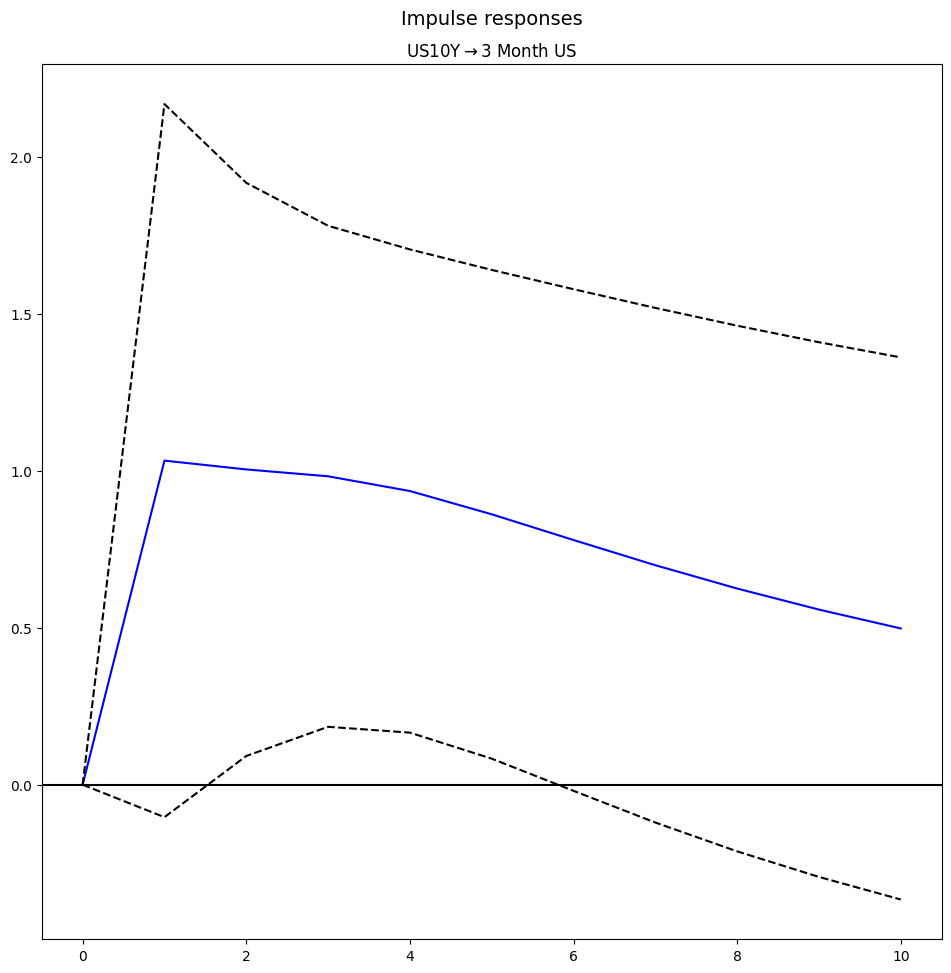

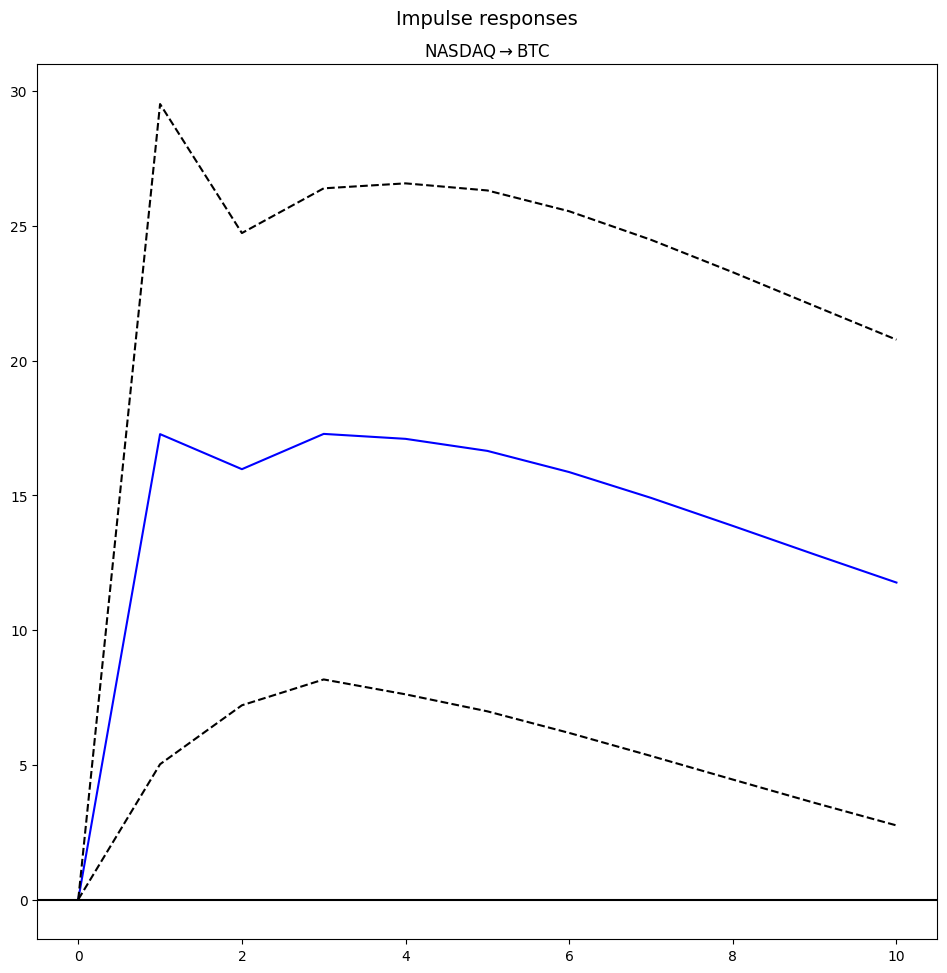

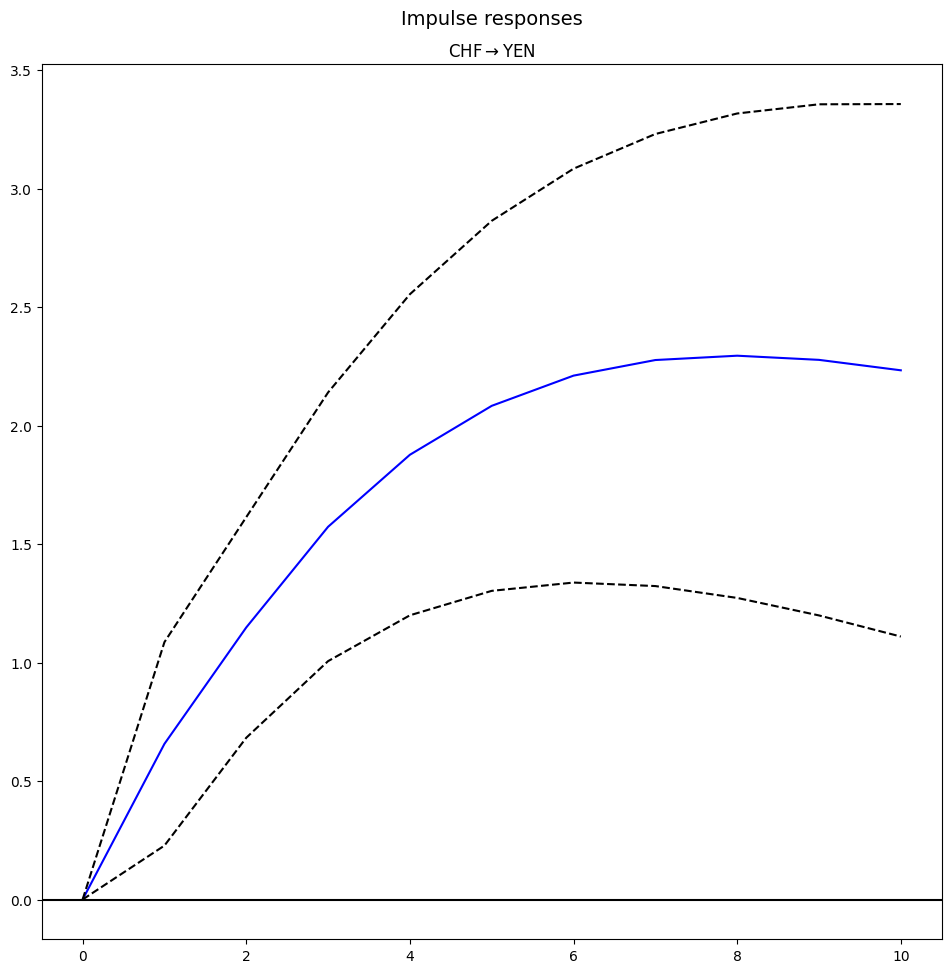

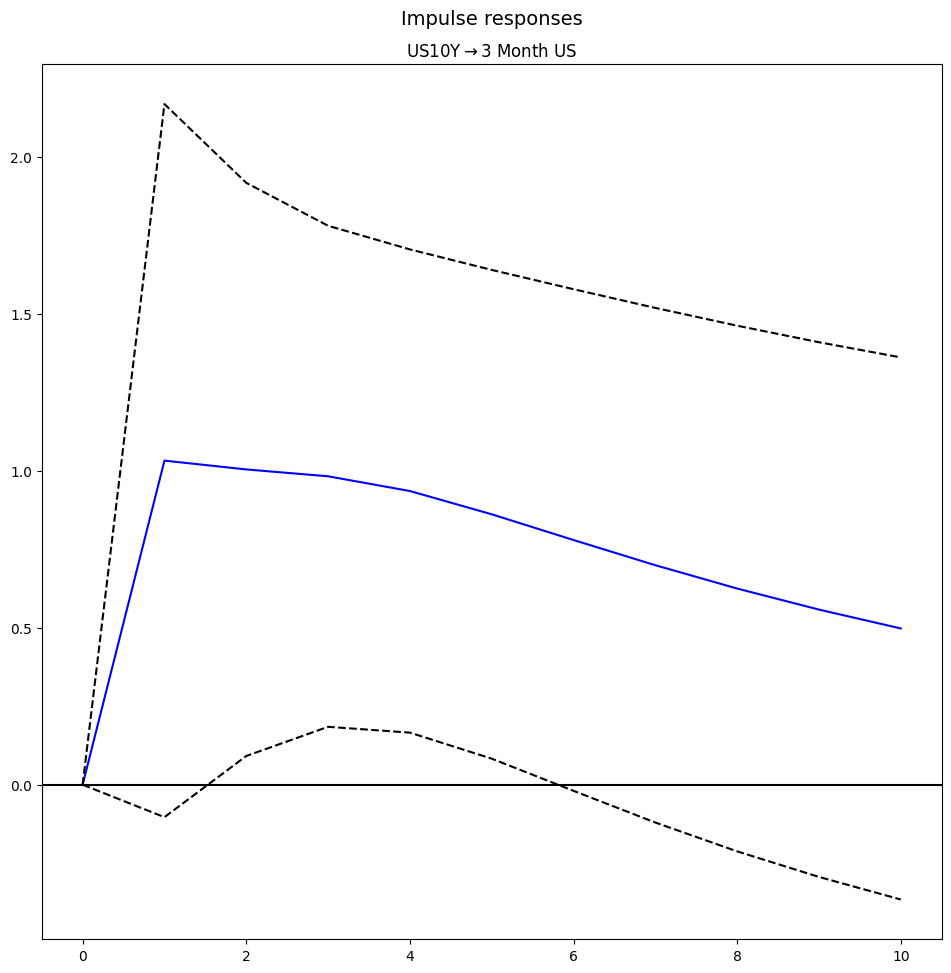

In [877]:
irf = model.irf(10)  # 10 weeks ahead

irf.plot(impulse='NASDAQ', response='BTC')
irf.plot(impulse='CHF', response='YEN')
irf.plot(impulse='US10Y', response='3 Month US')

## LM

In [878]:
df_corr = pd.DataFrame()
variable = 'Levered Ratio'
for instrument in cot_clean['Instrument'].unique().tolist():
    ### this is fucken insane idk wtf goin on here bro
    temp = pd.DataFrame(cot_clean[cot_clean['Instrument'] == instrument].set_index('Report_Date_as_MM_DD_YYYY').drop(columns = 'Instrument')[variable]).rename(columns={variable : instrument})
    df_corr = df_corr.join(temp, how="outer")

In [879]:
df_corr.replace([np.inf, -np.inf], np.nan, inplace=True)
df_corr = df_corr.dropna()

df_corr

,1 Month US,3 Month US,BTC,CAD,CHF,GBP,NASDAQ,SP500,US10Y,YEN,russel
Report_Date_as_MM_DD_YYYY,,,,,,,,,,,
2018-07-24,0.156715,0.272886,0.584955,0.196933,0.246361,0.716190,0.940205,0.688411,0.510746,0.376155,0.956359
2018-07-31,0.046664,0.839063,0.874556,0.251773,0.275052,0.731013,0.942603,0.785947,0.480921,0.390110,0.999122
2018-08-07,0.040419,1.093368,1.018569,0.383928,0.252436,0.651617,0.856877,0.712914,0.520480,0.370137,1.053055
2018-08-14,0.057697,0.695787,1.169309,0.336912,0.238928,0.676966,0.913697,0.742710,0.516642,0.399328,1.138419
2018-08-21,0.042058,0.845504,1.144723,0.373837,0.279389,0.594595,0.904986,0.659798,0.507369,0.530911,1.076556
...,...,...,...,...,...,...,...,...,...,...,...
2026-02-17,0.401400,0.384539,1.327203,0.368820,1.471226,2.240431,0.595079,0.457934,0.244529,0.740029,0.815418
2026-02-24,0.416448,0.402763,0.785803,0.413219,1.573921,2.175464,0.529472,0.458457,0.250477,0.743181,0.699630
2026-03-03,0.346414,0.390147,1.204733,0.392167,1.542821,1.662478,0.450201,0.528789,0.217368,0.660560,0.709306


In [880]:
desc = df_corr.describe().T
desc["skewness"] = df_corr.skew()
desc["kurtosis"] = df_corr.kurtosis()  # excess kurtosis (normal = 0)
desc[["mean", "std", "min", "25%", "50%", "75%", "max", "skewness", "kurtosis"]]

,mean,std,min,25%,50%,75%,max,skewness,kurtosis
1 Month US,1.574629,1.814514,0.040419,0.556192,1.055723,1.892037,15.186110,3.539374,17.088519
3 Month US,1.989372,1.965097,0.077623,0.659693,1.332508,2.286235,12.472816,2.105899,5.113540
BTC,0.553184,0.266763,0.146254,0.341276,0.513536,0.725351,1.549943,0.728973,0.058034
CAD,0.586818,0.444063,0.033286,0.259316,0.413517,0.836282,2.171241,1.235272,0.897957
CHF,1.250010,1.064962,0.136763,0.562930,0.867604,1.473541,6.333228,1.711625,2.678960
GBP,1.315725,0.561936,0.341179,0.898152,1.175170,1.675244,3.284708,0.696909,0.083458
NASDAQ,0.711474,0.240132,0.301399,0.544900,0.665957,0.846776,1.782512,1.429378,3.665512
SP500,0.635341,0.209882,0.291455,0.485404,0.581702,0.728254,1.585926,1.375476,2.244546
US10Y,0.588434,0.525801,0.128032,0.236121,0.352544,0.709812,2.035074,1.381700,0.430053
YEN,0.673843,0.559691,0.151903,0.346936,0.478512,0.787265,4.788722,3.071580,13.794958


In [881]:
var = VAR(df_corr)
lag_results = var.select_order(maxlags=8)
print(lag_results.summary())
p_opt = lag_results.selected_orders['aic']

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -17.27      -17.16   3.167e-08      -17.22
1     -34.93*     -33.59*  6.777e-16*     -34.40*
2      -34.70      -32.14   8.490e-16      -33.69
3      -34.69      -30.90   8.618e-16      -33.19
4      -34.50      -29.47   1.053e-15      -32.51
5      -34.27      -28.02   1.334e-15      -31.79
6      -34.11      -26.63   1.586e-15      -31.15
7      -34.00      -25.29   1.815e-15      -30.55
8      -33.87      -23.93   2.141e-15      -29.93
-------------------------------------------------


/opt/anaconda3/envs/quantlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [882]:
model = var.fit(maxlags=p_opt, ic='aic')
print(model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 23, Mar, 2026
Time:                     17:37:35
--------------------------------------------------------------------
No. of Equations:         11.0000    BIC:                   -33.6811
Nobs:                     398.000    HQIC:                  -34.4796
Log likelihood:           885.534    FPE:                6.28593e-16
AIC:                     -35.0032    Det(Omega_mle):     4.53379e-16
--------------------------------------------------------------------
Results for equation 1 Month US
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.246263         0.227539            1.082           0.279
L1.1 Month US         0.928484         0.019249           48.236           0.000
L1.3 Month US         0.013854         0.019751        

In [883]:
LM_Pair_1 = ['NASDAQ', 'YEN', 'GBP', 'SP500', '3 Month US']
LM_Pair_2 = ['russel', 'NASDAQ', 'BTC', 'US10Y', 'US10Y']

In [884]:
for i in range(0, len(LM_Pair_1)):
    gc = model.test_causality(LM_Pair_2[i], causing=LM_Pair_1[i], kind='f')
    print('Testing', LM_Pair_2[i], "and", LM_Pair_1[i])
    print(gc.summary())

Testing russel and NASDAQ
Granger causality F-test. H_0: NASDAQ does not Granger-cause russel. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
       0.08852          3.844   0.766 (1, np.int64(4246))
---------------------------------------------------------
Testing NASDAQ and YEN
Granger causality F-test. H_0: YEN does not Granger-cause NASDAQ. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         3.324          3.844   0.068 (1, np.int64(4246))
---------------------------------------------------------
Testing BTC and GBP
Granger causality F-test. H_0: GBP does not Granger-cause BTC. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
------------------------------------------------

In [885]:
for i in range(0, len(LM_Pair_1)):
    gc = model.test_causality(LM_Pair_1[i], causing=LM_Pair_2[i], kind='f')
    print('Testing', LM_Pair_2[i], "and", LM_Pair_1[i])
    print(gc.summary())

Testing russel and NASDAQ
Granger causality F-test. H_0: russel does not Granger-cause NASDAQ. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         6.179          3.844   0.013 (1, np.int64(4246))
---------------------------------------------------------
Testing NASDAQ and YEN
Granger causality F-test. H_0: NASDAQ does not Granger-cause YEN. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         4.143          3.844   0.042 (1, np.int64(4246))
---------------------------------------------------------
Testing BTC and GBP
Granger causality F-test. H_0: BTC does not Granger-cause GBP. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
      

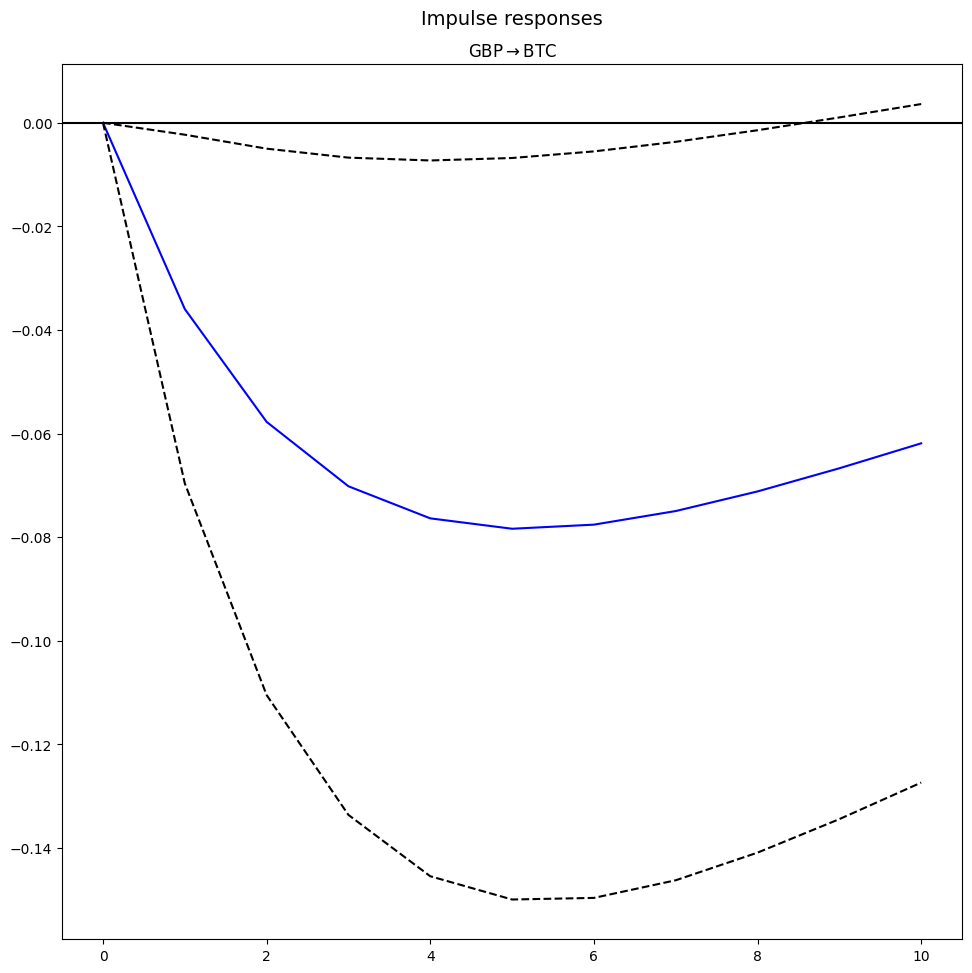

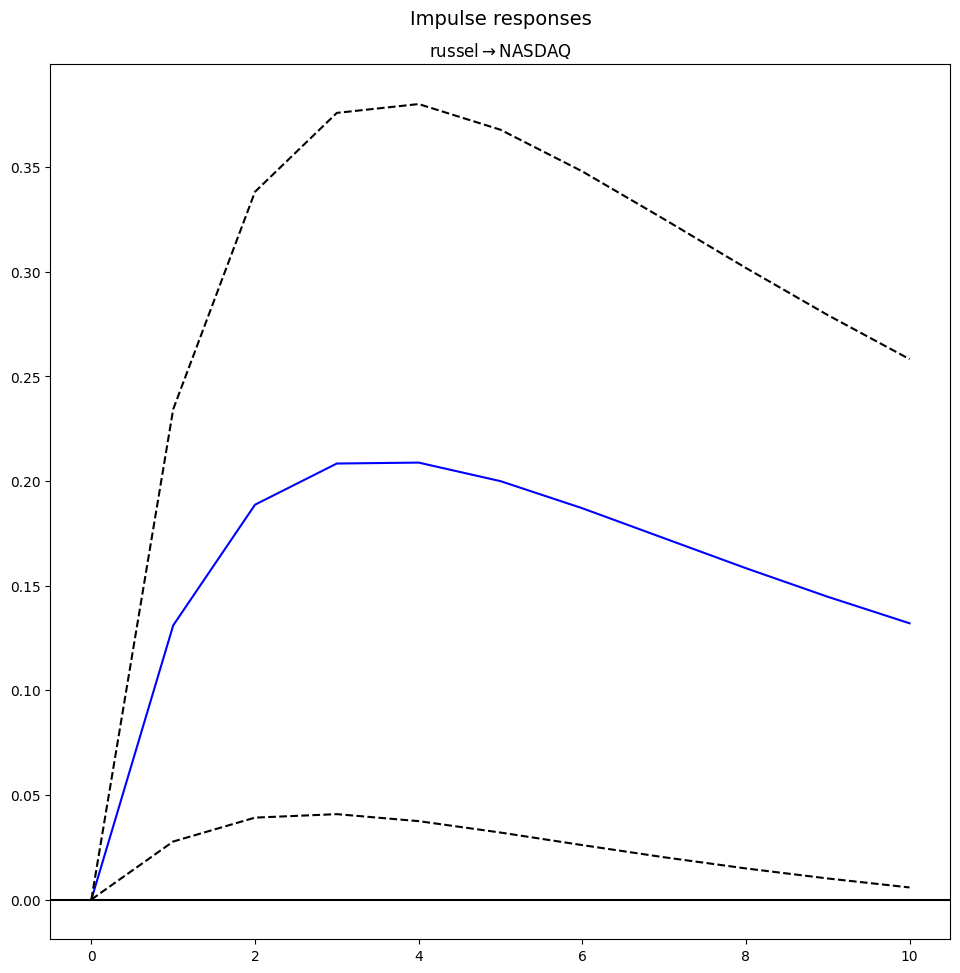

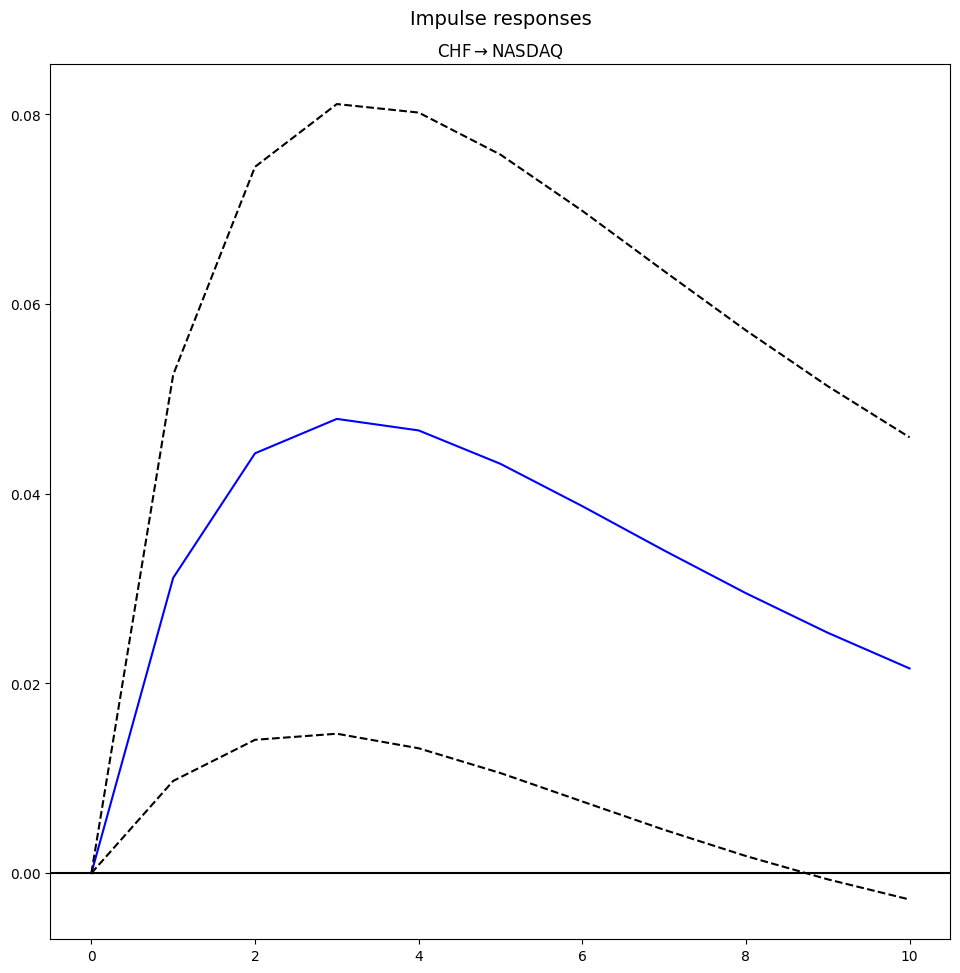

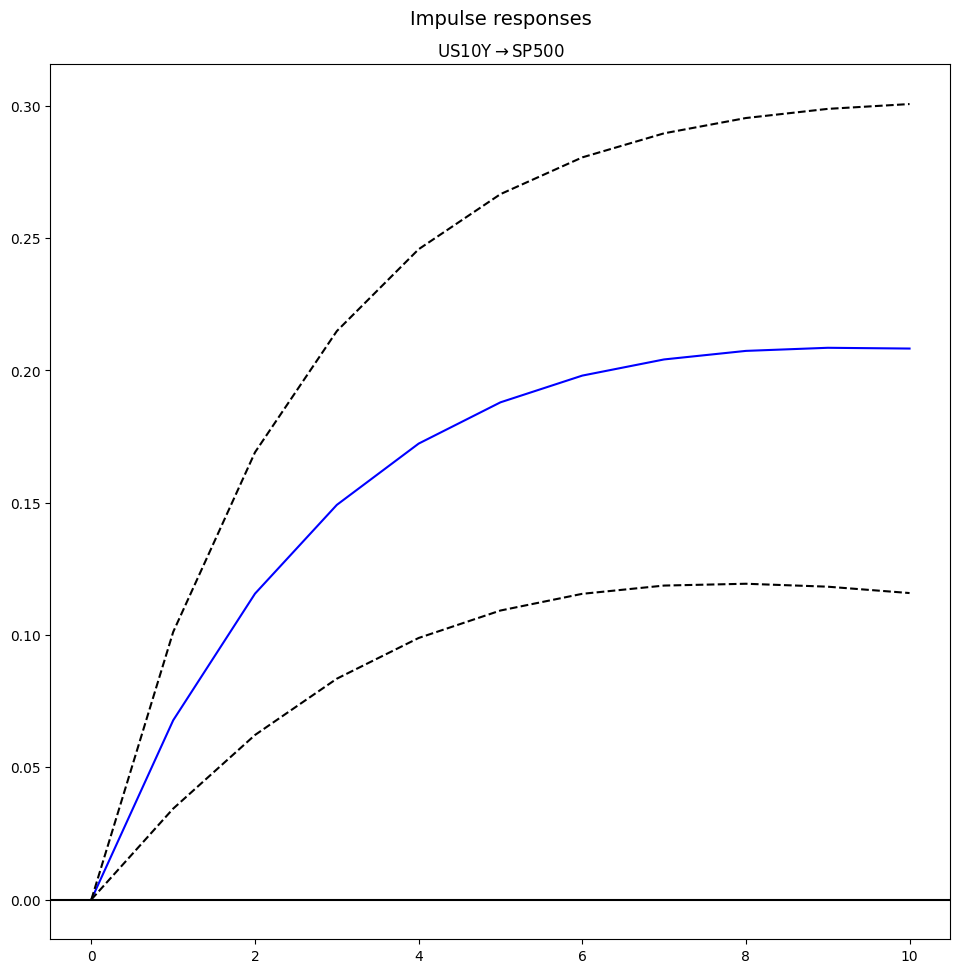

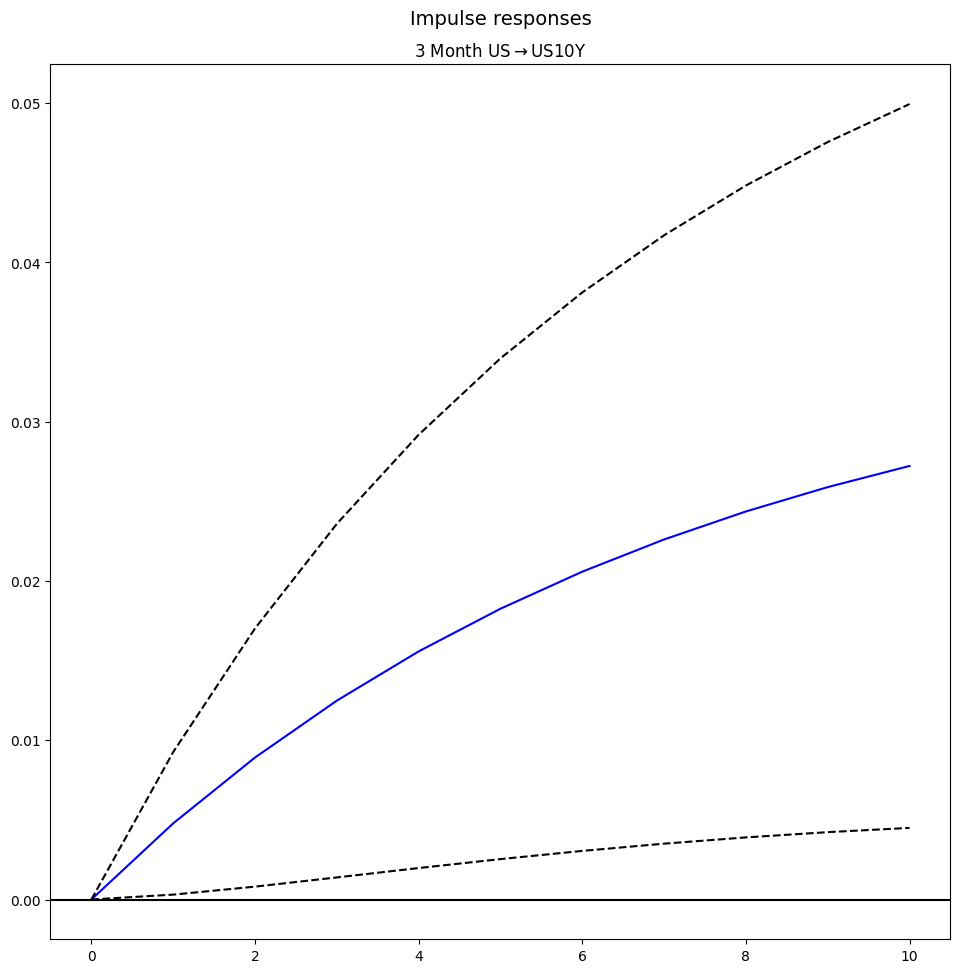

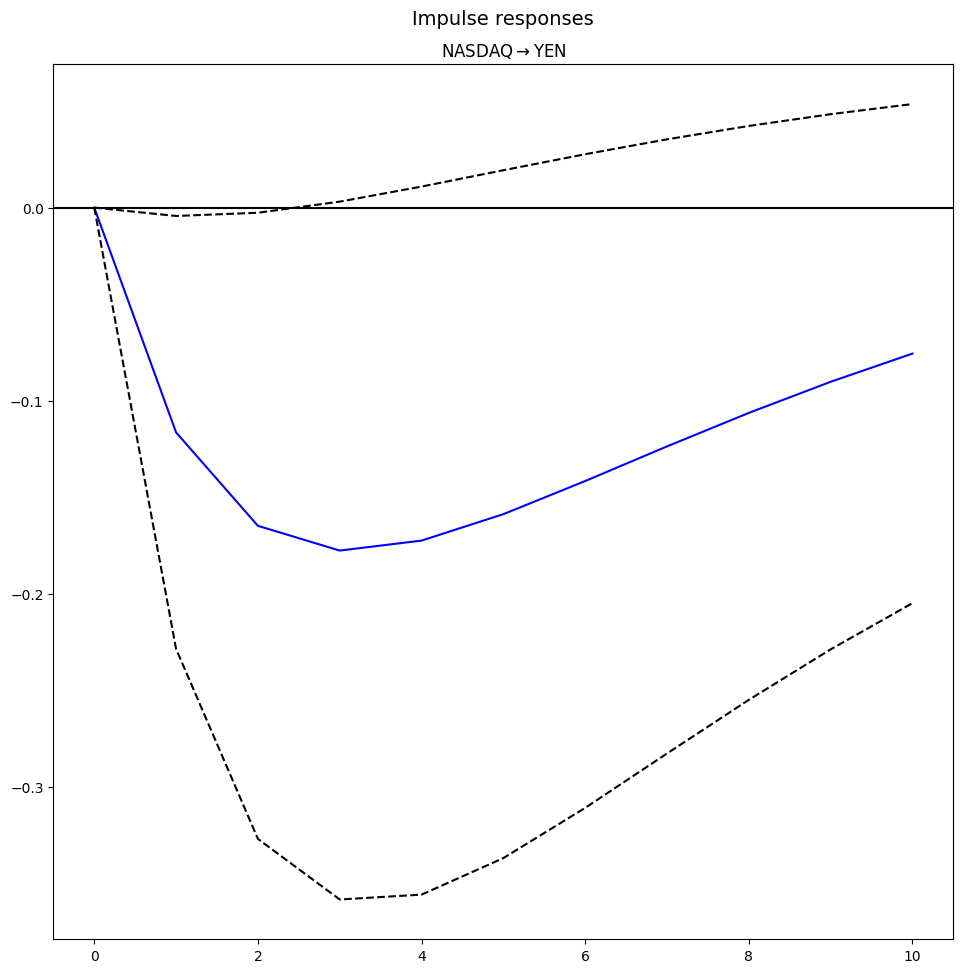

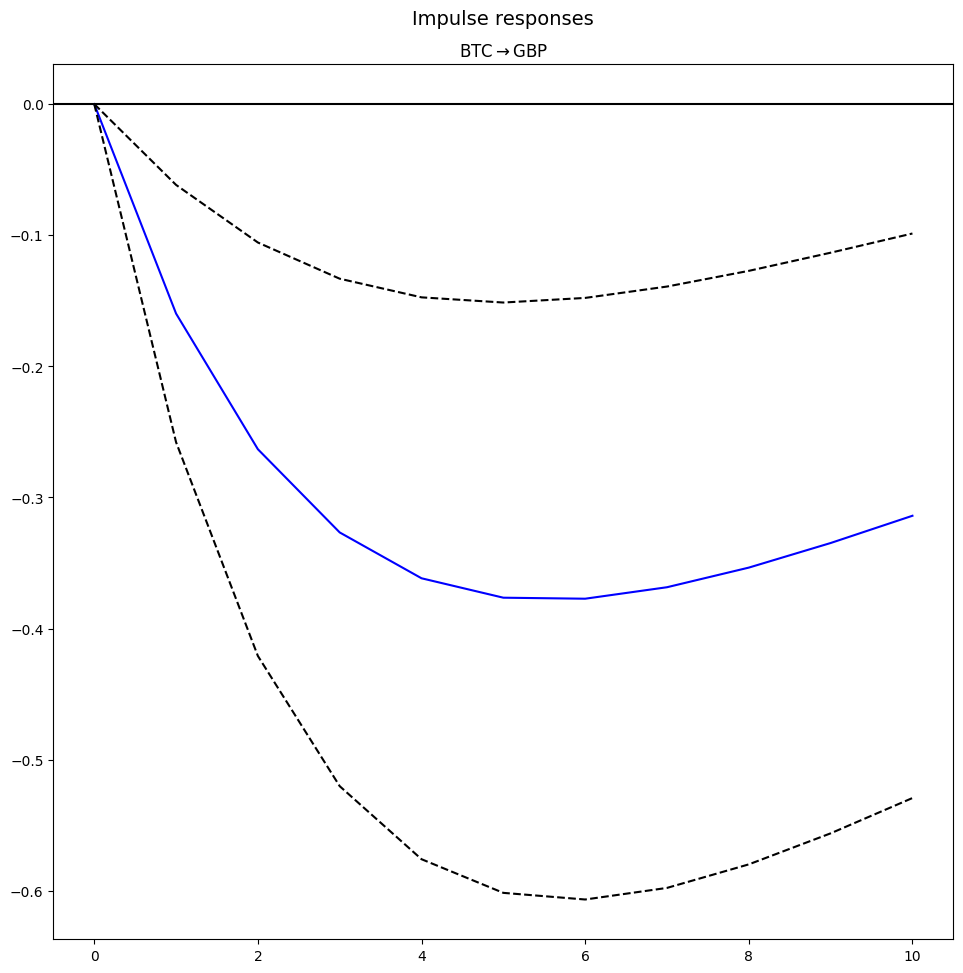

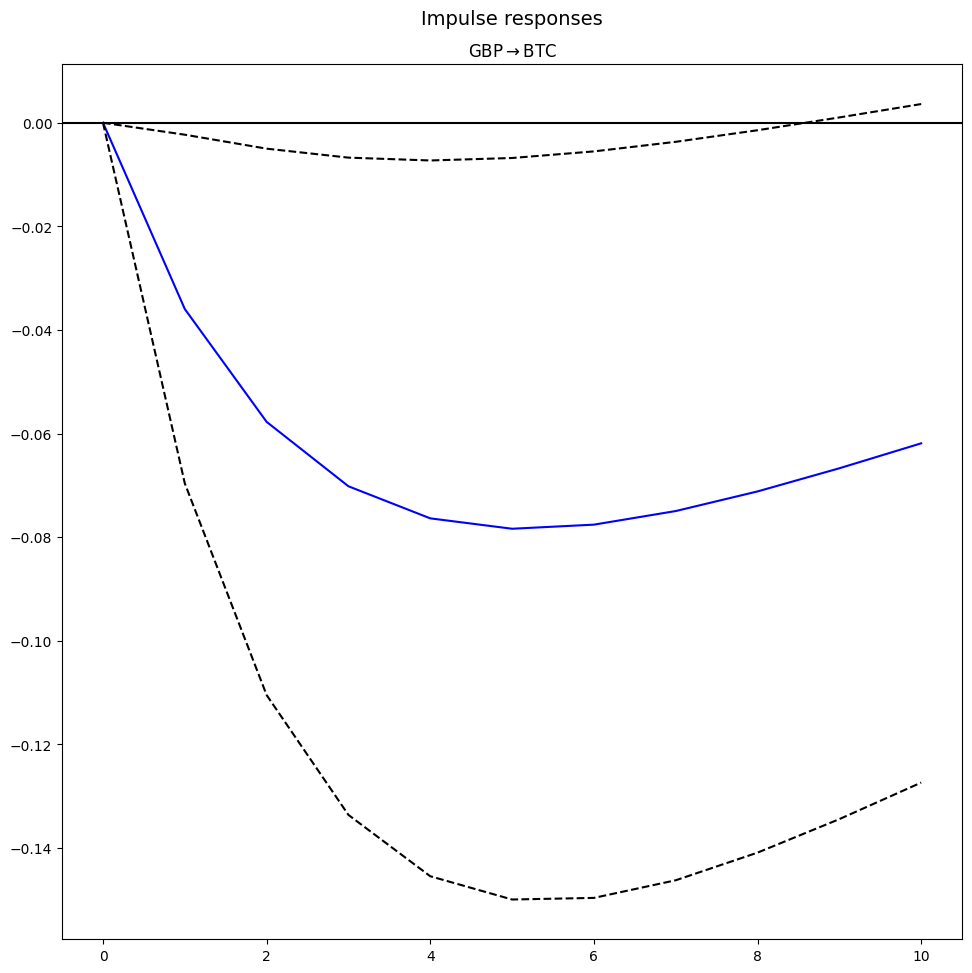

In [886]:
irf = model.irf(10)

# Clean one-directional signals
irf.plot(impulse='russel', response='NASDAQ')
irf.plot(impulse='CHF', response='NASDAQ')
irf.plot(impulse='US10Y', response='SP500')
irf.plot(impulse='3 Month US', response='US10Y')
irf.plot(impulse='NASDAQ', response='YEN')

# Bidirectional pair
irf.plot(impulse='BTC', response='GBP')
irf.plot(impulse='GBP', response='BTC')

## Dealers

In [887]:
df_corr = pd.DataFrame()
variable = 'Dealer Ratio'
for instrument in cot_clean['Instrument'].unique().tolist():
    ### this is fucken insane idk wtf goin on here bro
    temp = pd.DataFrame(cot_clean[cot_clean['Instrument'] == instrument].set_index('Report_Date_as_MM_DD_YYYY').drop(columns = 'Instrument')[variable]).rename(columns={variable : instrument})
    df_corr = df_corr.join(temp, how="outer")

df_corr.replace([np.inf, -np.inf], np.nan, inplace=True)
df_corr = df_corr.dropna()

df_corr

,1 Month US,3 Month US,BTC,CAD,CHF,GBP,NASDAQ,SP500,US10Y,YEN,russel
Report_Date_as_MM_DD_YYYY,,,,,,,,,,,
2018-10-02,2.783244,0.641786,0.000000,0.755645,6.522646,2.493739,0.533693,0.263396,0.475286,92.219828,0.389624
2018-10-09,3.332052,0.674991,0.000000,0.590825,10.720515,2.282105,0.993597,0.402903,0.488933,83.195796,0.537118
2018-10-16,2.728022,0.720450,0.000000,0.534894,14.432533,1.783969,1.207845,0.458560,0.431198,95.178355,0.667560
2018-10-23,3.441754,0.724203,0.000000,0.688946,15.695451,1.795475,1.272607,0.522732,0.393676,64.497214,0.890090
2019-01-15,5.933586,0.242728,0.000000,24.233533,3.018278,3.067545,2.457301,0.297449,0.296174,0.856808,1.495944
...,...,...,...,...,...,...,...,...,...,...,...
2026-02-17,2.547516,1.725694,2.584910,0.366565,6.040217,1.274560,0.644746,0.332242,0.422285,0.261050,0.791873
2026-02-24,3.485741,1.703297,2.238516,0.401209,6.724655,1.947207,0.786996,0.334797,0.460345,0.348543,0.910536
2026-03-03,3.684482,1.748018,2.136279,0.479316,7.042796,2.713676,1.032888,0.324632,0.493706,0.670746,0.897935


In [888]:
var = VAR(df_corr)
lag_results = var.select_order(maxlags=8)
print(lag_results.summary())
p_opt = lag_results.selected_orders['aic']

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       23.71       23.84   1.985e+10       23.76
1      10.04*      11.61*  2.294e+04*      10.67*
2       10.05       13.06   2.318e+04       11.25
3       10.12       14.57   2.504e+04       11.90
4       10.35       16.24   3.178e+04       12.70
5       10.68       18.01   4.514e+04       13.61
6       10.66       19.44   4.585e+04       14.17
7       10.73       20.95   5.117e+04       14.81
8       10.88       22.54   6.325e+04       15.54
-------------------------------------------------


/opt/anaconda3/envs/quantlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [889]:
model = var.fit(maxlags=p_opt, ic='aic')
print(model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 23, Mar, 2026
Time:                     17:37:35
--------------------------------------------------------------------
No. of Equations:         11.0000    BIC:                    11.9146
Nobs:                     322.000    HQIC:                   10.9851
Log likelihood:          -6563.02    FPE:                    31814.9
AIC:                      10.3673    Det(Omega_mle):         21273.2
--------------------------------------------------------------------
Results for equation 1 Month US
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.196126         0.112437            1.744           0.081
L1.1 Month US         0.892374         0.026161           34.110           0.000
L1.3 Month US         0.058048         0.055872        

In [890]:
D_Pair_1 = ['NASDAQ', 'NASDAQ', 'russel', 'BTC', '3 Month US']
D_Pair_2 = ['YEN', 'CHF', 'SP500','US10Y', 'russel' ]

In [891]:
for i in range(0, len(D_Pair_1)):
    gc = model.test_causality(D_Pair_2[i], causing=D_Pair_1[i], kind='f')
    print('Testing', D_Pair_2[i], "and", D_Pair_1[i])
    print(gc.summary())

Testing YEN and NASDAQ
Granger causality F-test. H_0: NASDAQ does not Granger-cause YEN. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         17.03          3.844   0.000 (1, np.int64(3410))
---------------------------------------------------------
Testing CHF and NASDAQ
Granger causality F-test. H_0: NASDAQ does not Granger-cause CHF. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         6.835          3.844   0.009 (1, np.int64(3410))
---------------------------------------------------------
Testing SP500 and russel
Granger causality F-test. H_0: russel does not Granger-cause SP500. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
  

In [892]:
for i in range(0, len(D_Pair_1)):
    gc = model.test_causality(D_Pair_1[i], causing=D_Pair_2[i], kind='f')
    print('Testing', D_Pair_2[i], "and", D_Pair_1[i])
    print(gc.summary())

Testing YEN and NASDAQ
Granger causality F-test. H_0: YEN does not Granger-cause NASDAQ. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         8.451          3.844   0.004 (1, np.int64(3410))
---------------------------------------------------------
Testing CHF and NASDAQ
Granger causality F-test. H_0: CHF does not Granger-cause NASDAQ. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         1.363          3.844   0.243 (1, np.int64(3410))
---------------------------------------------------------
Testing SP500 and russel
Granger causality F-test. H_0: SP500 does not Granger-cause russel. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
--------------------------------------------

In [893]:
df_corr

,1 Month US,3 Month US,BTC,CAD,CHF,GBP,NASDAQ,SP500,US10Y,YEN,russel
Report_Date_as_MM_DD_YYYY,,,,,,,,,,,
2018-10-02,2.783244,0.641786,0.000000,0.755645,6.522646,2.493739,0.533693,0.263396,0.475286,92.219828,0.389624
2018-10-09,3.332052,0.674991,0.000000,0.590825,10.720515,2.282105,0.993597,0.402903,0.488933,83.195796,0.537118
2018-10-16,2.728022,0.720450,0.000000,0.534894,14.432533,1.783969,1.207845,0.458560,0.431198,95.178355,0.667560
2018-10-23,3.441754,0.724203,0.000000,0.688946,15.695451,1.795475,1.272607,0.522732,0.393676,64.497214,0.890090
2019-01-15,5.933586,0.242728,0.000000,24.233533,3.018278,3.067545,2.457301,0.297449,0.296174,0.856808,1.495944
...,...,...,...,...,...,...,...,...,...,...,...
2026-02-17,2.547516,1.725694,2.584910,0.366565,6.040217,1.274560,0.644746,0.332242,0.422285,0.261050,0.791873
2026-02-24,3.485741,1.703297,2.238516,0.401209,6.724655,1.947207,0.786996,0.334797,0.460345,0.348543,0.910536
2026-03-03,3.684482,1.748018,2.136279,0.479316,7.042796,2.713676,1.032888,0.324632,0.493706,0.670746,0.897935


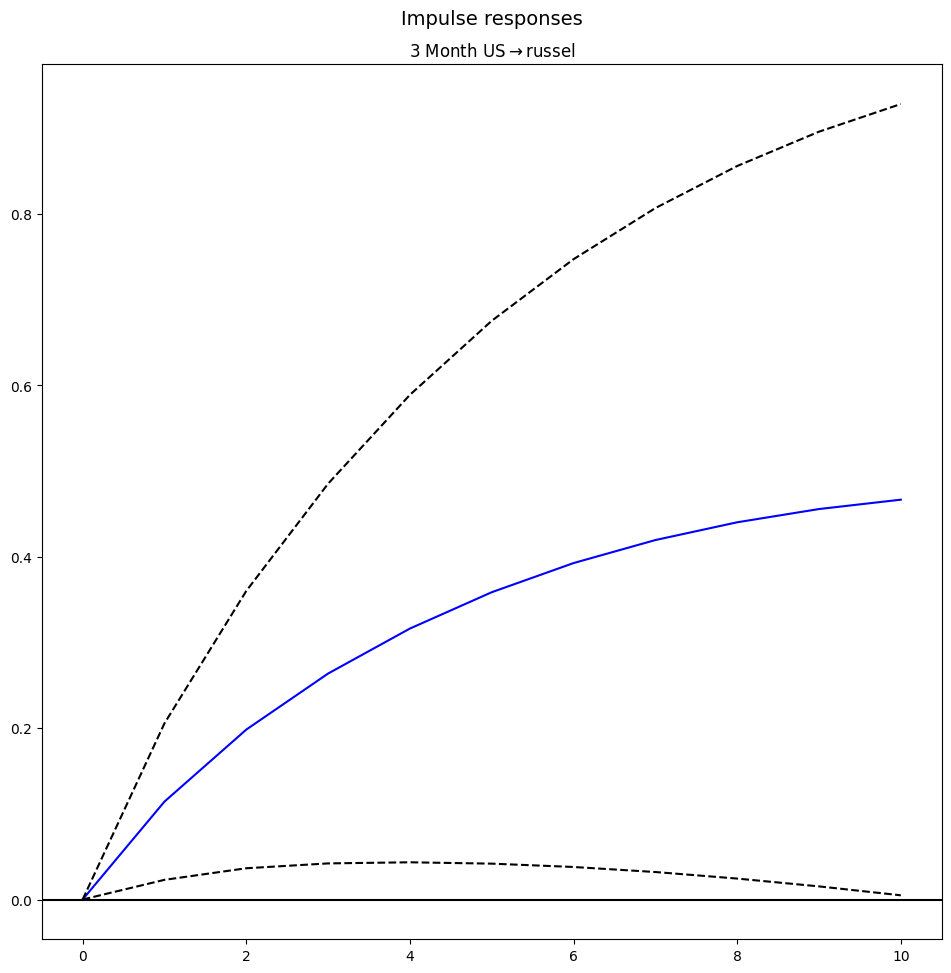

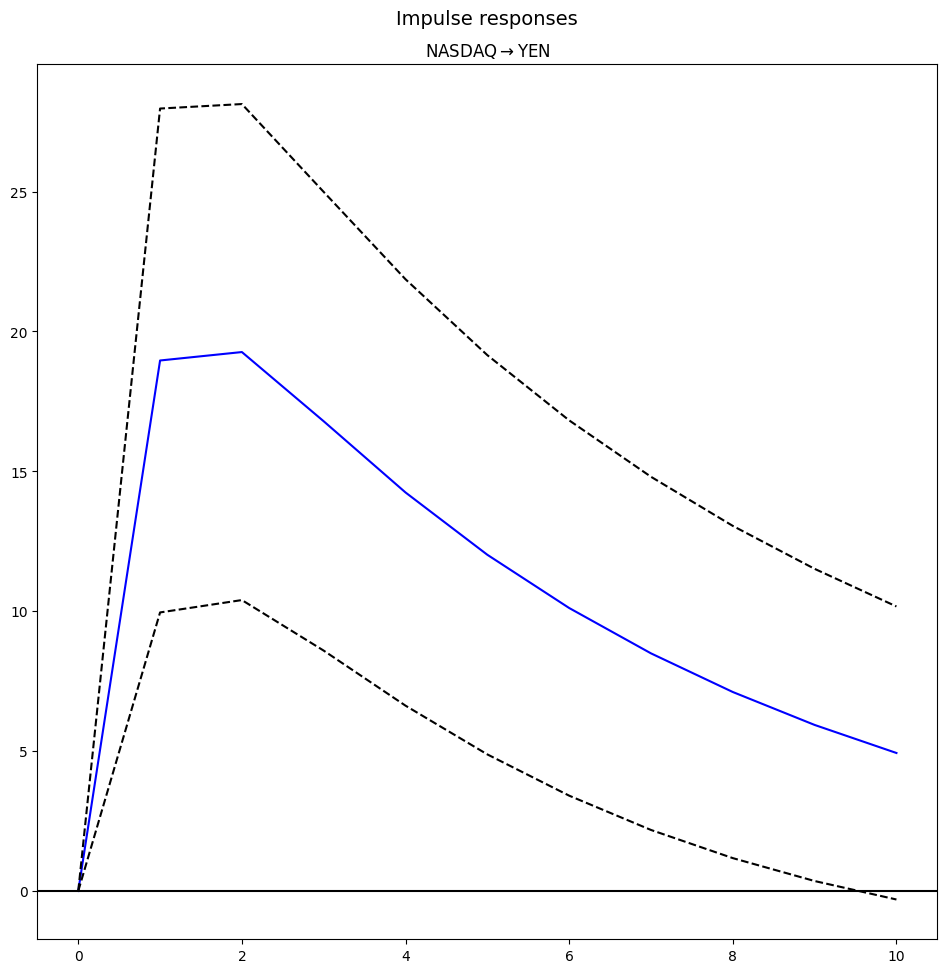

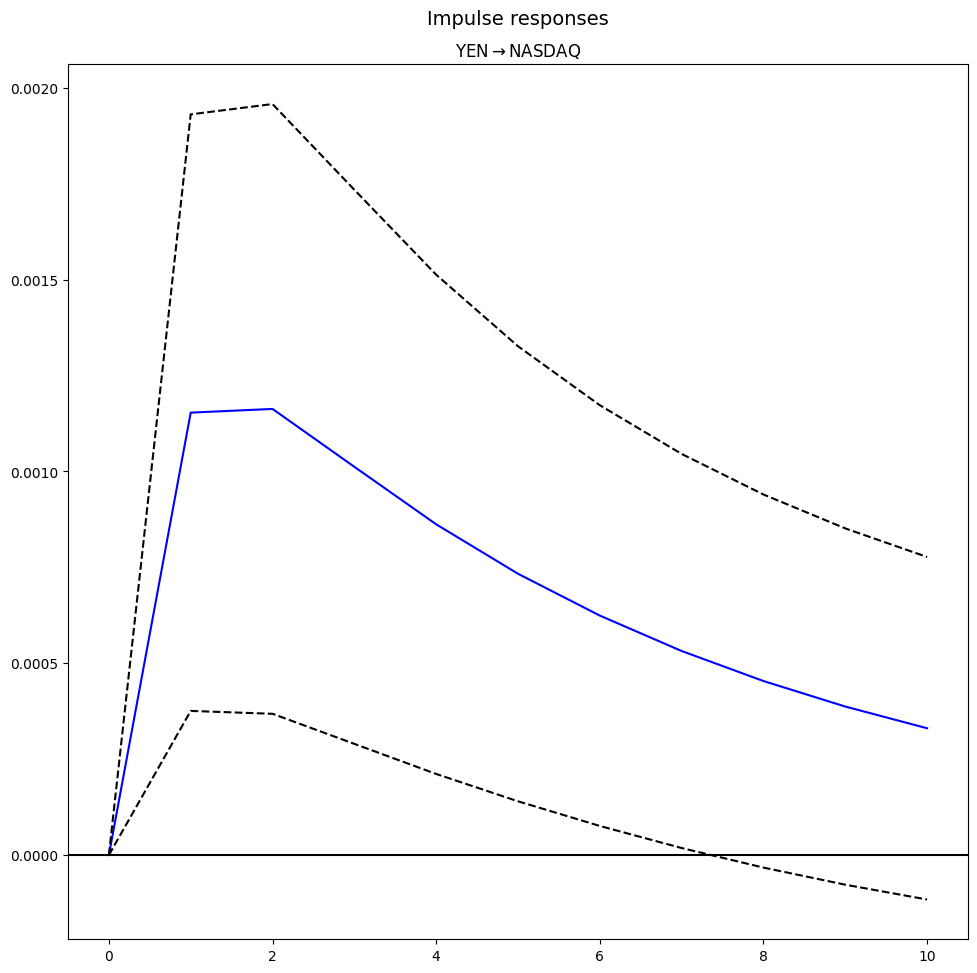

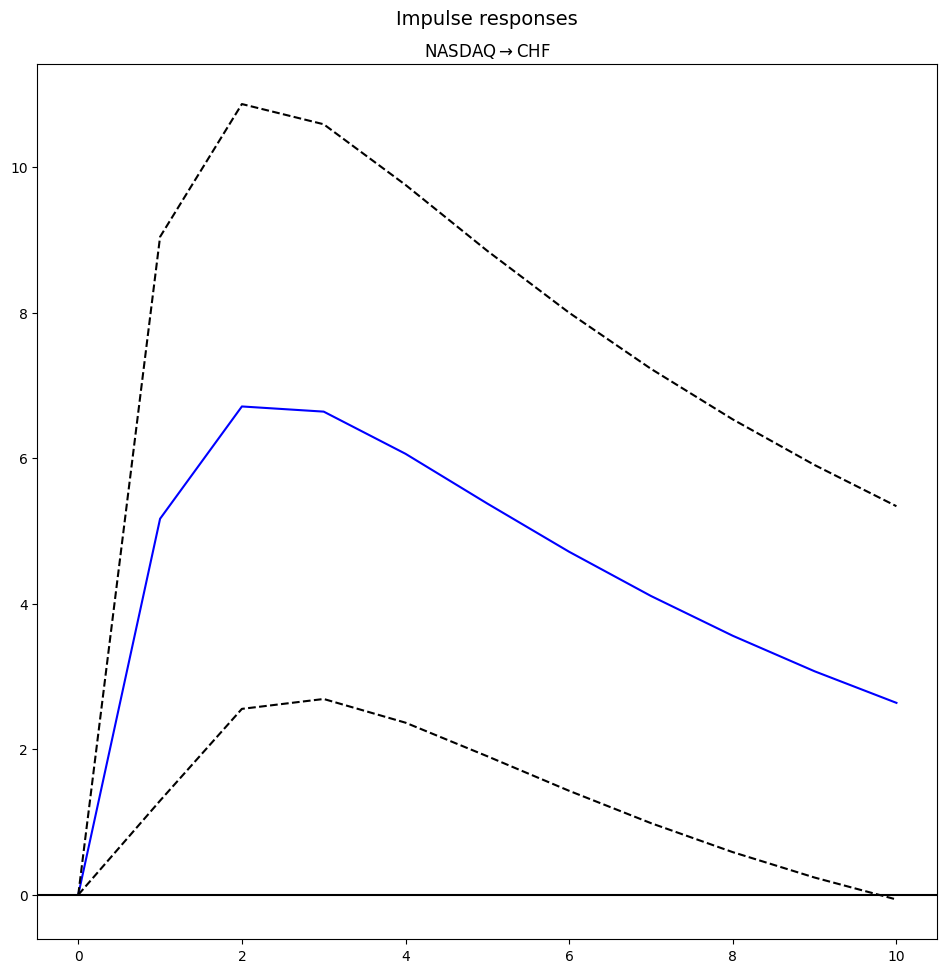

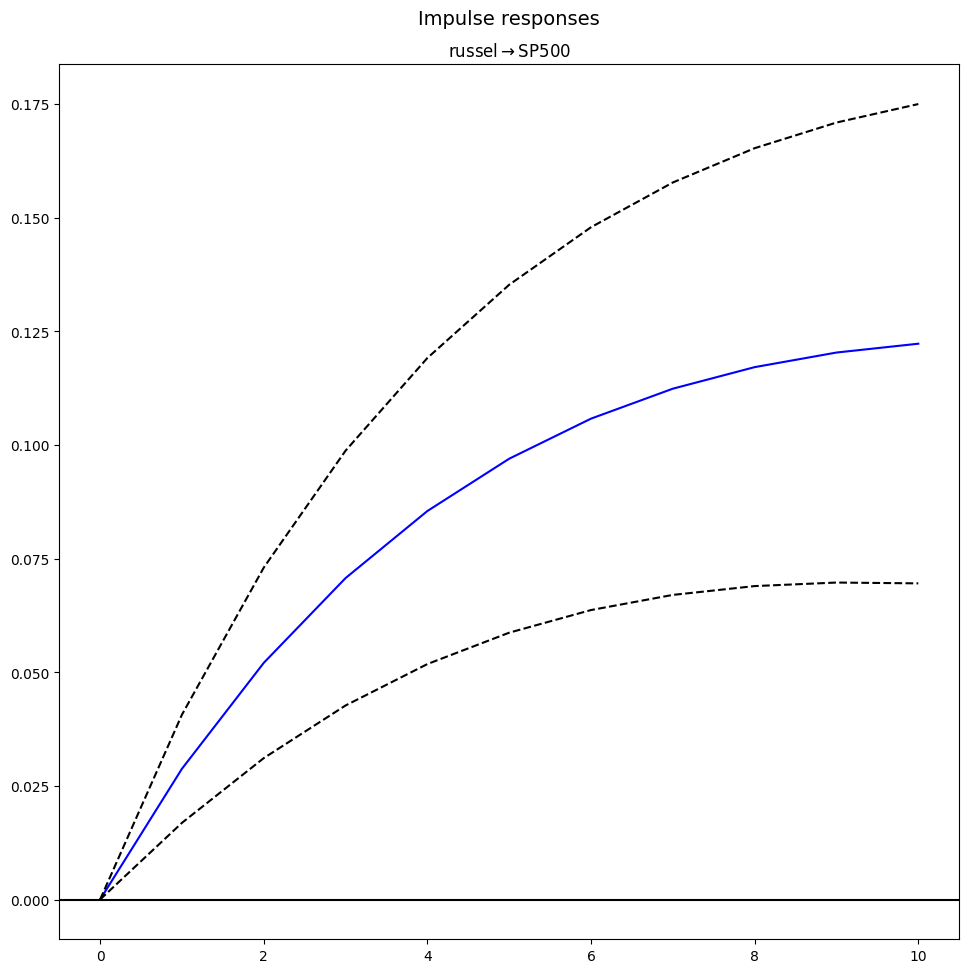

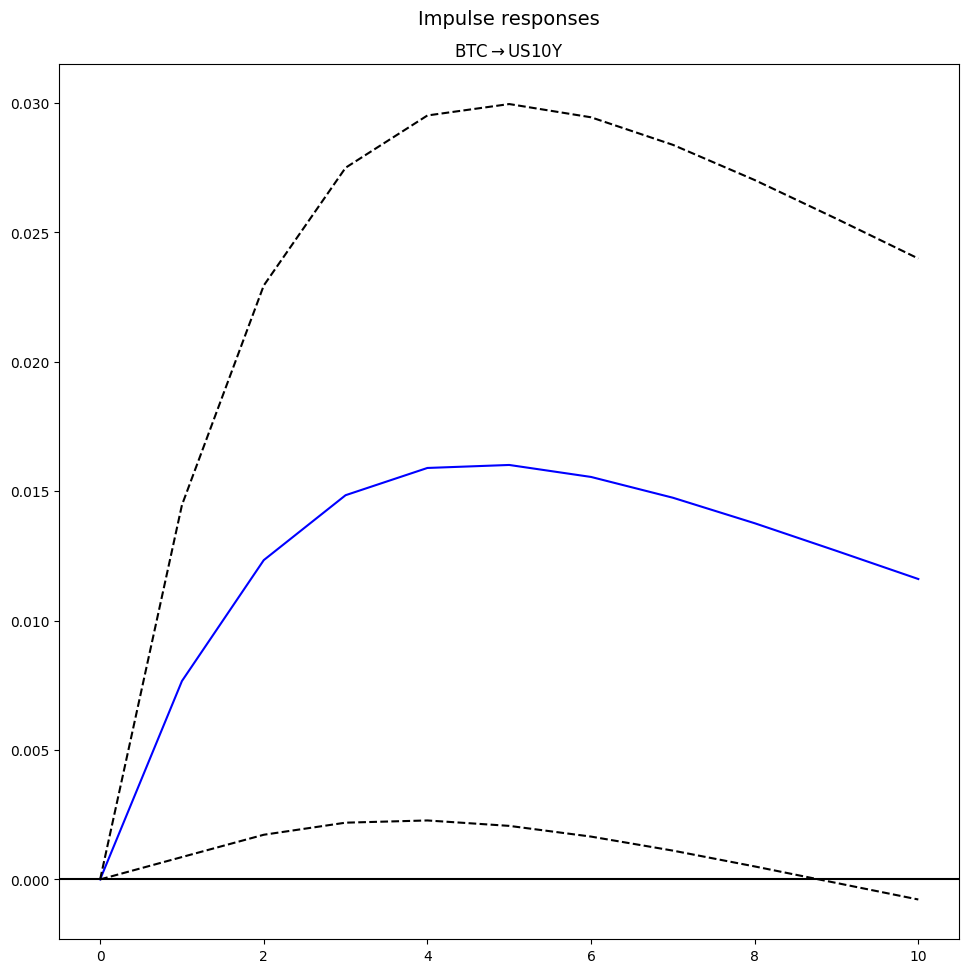

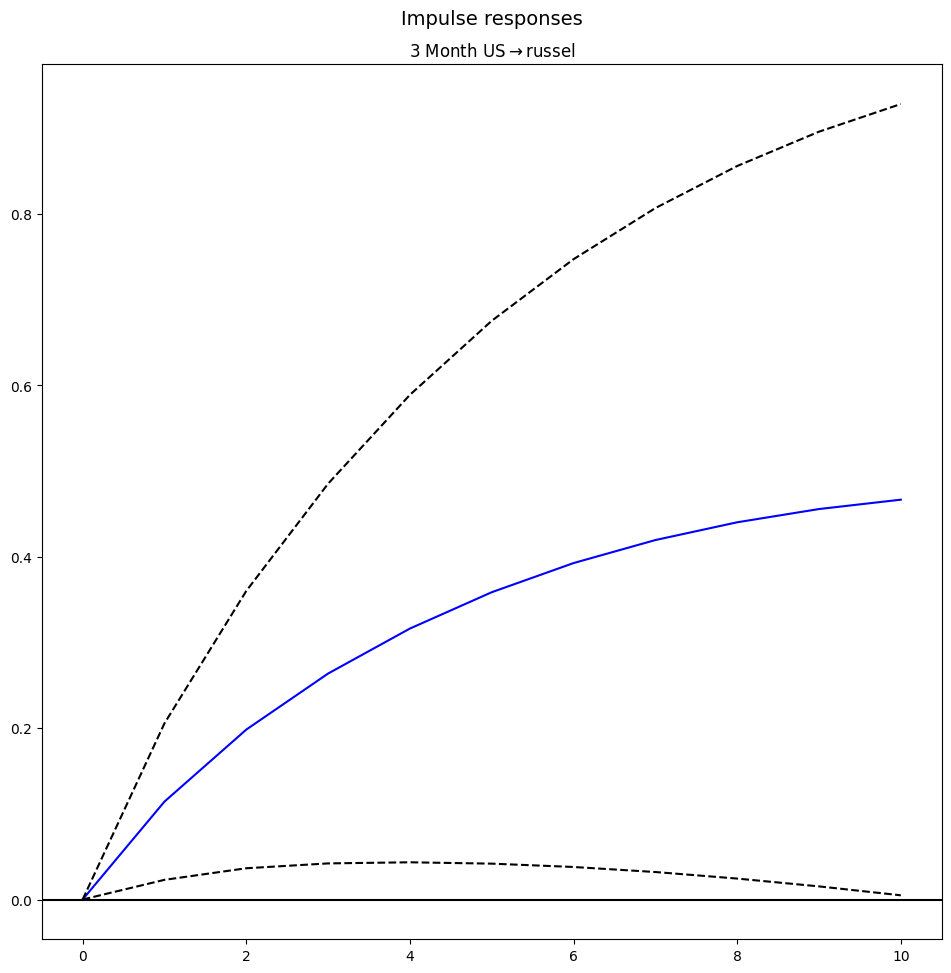

In [896]:
irf = model.irf(10)

# Clean one-directional signals
irf.plot(impulse='NASDAQ', response='YEN')
irf.plot(impulse='YEN', response='NASDAQ')      # bidirectional feedback leg
irf.plot(impulse='NASDAQ', response='CHF')
irf.plot(impulse='russel', response='SP500')
irf.plot(impulse='BTC', response='US10Y')
irf.plot(impulse='3 Month US', response='russel')

## Visualisation 

In [901]:
cot_clean['Instrument'].unique().tolist()

['1 Month US',
 '3 Month US',
 'BTC',
 'CAD',
 'CHF',
 'GBP',
 'NASDAQ',
 'SP500',
 'US10Y',
 'YEN',
 'russel']

In [904]:
cot_clean.columns.values.tolist()

['Instrument',
 'Report_Date_as_MM_DD_YYYY',
 'Open_Interest_All',
 'Dealer_Positions_Long_All',
 'Dealer_Positions_Short_All',
 'Asset_Mgr_Positions_Long_All',
 'Asset_Mgr_Positions_Short_All',
 'Lev_Money_Positions_Long_All',
 'Lev_Money_Positions_Short_All',
 'Dealer Net',
 'Asset Manager Net',
 'Levered Net',
 'Dealer Ratio',
 'Asset Manager Ratio',
 'Levered Ratio',
 'Dealer Long Proportion',
 'Asset Manager Long Proportion',
 'Levered Long Proportion',
 'Dealer Short Proportion',
 'Asset Manager Short Proportion',
 'Levered Short Proportion',
 'Dealer Crowding',
 'Asset Manager Crowding',
 'Levered Manager Crowding']

In [912]:
variable = 'Levered Net'
tf_in_weeks = 1  #Do this one

In [916]:
df_corr = pd.DataFrame()

for instrument in cot_clean['Instrument'].unique().tolist():
    ### this is fucken insane idk wtf goin on here bro
    temp = pd.DataFrame(cot_clean[cot_clean['Instrument'] == instrument].set_index('Report_Date_as_MM_DD_YYYY').drop(columns = 'Instrument')[variable]).rename(columns={variable : instrument})
    df_corr = df_corr.join(temp, how="outer")

df_corr.replace([np.inf, -np.inf], np.nan, inplace=True)
df_corr = df_corr.dropna()

df_corr

,1 Month US,3 Month US,BTC,CAD,CHF,GBP,NASDAQ,SP500,US10Y,YEN,russel
Report_Date_as_MM_DD_YYYY,,,,,,,,,,,
2018-07-24,-4025.0,-1247.0,-960.0,-45986,-31787,-12969,-4584,-179166,-584886,-61601,-6684
2018-07-31,-4944.0,-206.0,-247.0,-38503,-30334,-12623,-4520,-109077,-616964,-54812,-130
2018-08-07,-4487.0,107.0,27.0,-31071,-32143,-23728,-10778,-167576,-564569,-54160,7472
2018-08-14,-4230.0,-491.0,299.0,-31563,-31758,-27046,-5948,-145835,-632094,-51155,18474
2018-08-21,-5307.0,-256.0,266.0,-31429,-30907,-41406,-6670,-211603,-646658,-35769,11083
...,...,...,...,...,...,...,...,...,...,...,...
2026-02-17,-266028.0,-1515454.0,15194.0,-38264,2653,43492,-99620,-741844,-2315792,-29051,-19045
2026-02-24,-415431.0,-1490491.0,-18938.0,-33815,3882,39974,-113737,-749816,-2204840,-29623,-33673
2026-03-03,-387482.0,-1545512.0,18513.0,-38491,4253,28099,-157843,-645816,-2176580,-42672,-34428


In [921]:
prices_clean = prices.ffill()
prices_clean = prices_clean.dropna()
for entry in prices_clean.index:
    if entry in df_corr.index:
        noice = True
    else:
        prices_clean = prices_clean.drop(entry)

returns_dict = dict(prices_clean.pct_change().iloc[-1]*100)

df_corr_treemap = pd.DataFrame(index = df_corr.columns.values.tolist())
df_corr_treemap[variable] = df_corr.iloc[-1]
df_corr_treemap = df_corr_treemap.reset_index()
df_corr_treemap['parent'] = ''
df_corr_treemap['ticker'] = df_corr_treemap['index'].map(TICKER_MAP)
df_corr_treemap['return'] = df_corr_treemap['ticker'].map(returns_dict)
df_corr_treemap['absolute value'] = abs(df_corr_treemap[variable])
df_corr_treemap



,index,Levered Net,parent,ticker,return,absolute value
0,1 Month US,-407319.0,,SHV,0.063532,407319.0
1,3 Month US,-1180161.0,,SHV,0.063532,1180161.0
2,BTC,22963.0,,BTC-USD,5.713900,22963.0
3,CAD,-41869.0,,CAD=X,0.710953,41869.0
4,CHF,-370.0,,CHF=X,1.307397,370.0
5,GBP,6777.0,,GBPUSD=X,-0.824157,6777.0
6,NASDAQ,-158819.0,,QQQ,-0.733834,158819.0
7,SP500,-501975.0,,^GSPC,-0.964246,501975.0
8,US10Y,-2332808.0,,IEF,-0.259229,2332808.0
9,YEN,-72047.0,,JPY=X,0.796328,72047.0


In [922]:
fig = px.treemap(df_corr_treemap, names="index", parents='parent', values='absolute value', 
color='return', color_continuous_scale='rdbu', template='plotly_dark')
fig

#### Cross Manager

In [923]:
cot_clean['Instrument'].unique().tolist()

['1 Month US',
 '3 Month US',
 'BTC',
 'CAD',
 'CHF',
 'GBP',
 'NASDAQ',
 'SP500',
 'US10Y',
 'YEN',
 'russel']

In [924]:
cot_clean.columns.values.tolist()

['Instrument',
 'Report_Date_as_MM_DD_YYYY',
 'Open_Interest_All',
 'Dealer_Positions_Long_All',
 'Dealer_Positions_Short_All',
 'Asset_Mgr_Positions_Long_All',
 'Asset_Mgr_Positions_Short_All',
 'Lev_Money_Positions_Long_All',
 'Lev_Money_Positions_Short_All',
 'Dealer Net',
 'Asset Manager Net',
 'Levered Net',
 'Dealer Ratio',
 'Asset Manager Ratio',
 'Levered Ratio',
 'Dealer Long Proportion',
 'Asset Manager Long Proportion',
 'Levered Long Proportion',
 'Dealer Short Proportion',
 'Asset Manager Short Proportion',
 'Levered Short Proportion',
 'Dealer Crowding',
 'Asset Manager Crowding',
 'Levered Manager Crowding']

In [1147]:

feature = 'Ratio'

VARIABLE_MAP = {
                'Net':['Levered Net','Asset Manager Net' ],
                'Longs': ['Lev_Money_Positions_Long_All', 'Asset_Mgr_Positions_Long_All', ],
                'Ratio' : ['Asset Manager Ratio','Levered Ratio' ]
}

In [1148]:
VARIABLE_MAP[feature][0]

'Asset Manager Ratio'

In [1149]:
specific_feature_name = VARIABLE_MAP[feature][0]
df_levered = pd.DataFrame()

for instrument in cot_clean['Instrument'].unique().tolist():
    ### this is fucken insane idk wtf goin on here bro
    temp = pd.DataFrame(cot_clean[cot_clean['Instrument'] == instrument].set_index('Report_Date_as_MM_DD_YYYY').drop(columns = 'Instrument')[specific_feature_name]).rename(columns={specific_feature_name : instrument})
    df_levered = df_levered.join(temp, how="outer")

df_levered.replace([np.inf, -np.inf], np.nan, inplace=True)
df_levered = df_levered.dropna()


prices_clean = prices.ffill()
prices_clean = prices_clean.dropna()
for entry in prices_clean.index:
    if entry in df_levered.index:
        noice = True
    else:
        prices_clean = prices_clean.drop(entry)


returns_dict = dict(prices_clean.pct_change().iloc[-1]*100)
returns_dict

df_levered_treemap = pd.DataFrame(index = df_levered.columns.values.tolist())
df_levered_treemap[feature] = df_levered.iloc[-1]
df_levered_treemap = df_levered_treemap.reset_index()
df_levered_treemap['parent'] = 'Levered'
df_levered_treemap['ticker'] = df_levered_treemap['index'].map(TICKER_MAP)
df_levered_treemap['return'] = df_levered_treemap['ticker'].map(returns_dict)
df_levered_treemap['absolute value'] = abs(df_levered_treemap[feature])

df_levered_treemap

df_levered_treemap


,index,Ratio,parent,ticker,return,absolute value
0,1 Month US,2.812728,Levered,SHV,0.063532,2.812728
1,3 Month US,1.012527,Levered,SHV,0.063532,1.012527
2,BTC,2.805385,Levered,BTC-USD,5.713900,2.805385
3,CAD,1.735572,Levered,CAD=X,0.710953,1.735572
4,CHF,0.139462,Levered,CHF=X,1.307397,0.139462
5,GBP,0.388328,Levered,GBPUSD=X,-0.824157,0.388328
6,NASDAQ,2.711558,Levered,QQQ,-0.733834,2.711558
7,SP500,4.271356,Levered,^GSPC,-0.964246,4.271356
8,US10Y,2.810693,Levered,IEF,-0.259229,2.810693
9,YEN,1.026244,Levered,JPY=X,0.796328,1.026244


In [1150]:
VARIABLE_MAP[feature][1]

'Levered Ratio'

In [1151]:
specific_feature_name = VARIABLE_MAP[feature][1]
df_asset_manager = pd.DataFrame()

for instrument in cot_clean['Instrument'].unique().tolist():
    ### this is fucken insane idk wtf goin on here bro
    temp = pd.DataFrame(cot_clean[cot_clean['Instrument'] == instrument].set_index('Report_Date_as_MM_DD_YYYY').drop(columns = 'Instrument')[VARIABLE_MAP[feature][1]]).rename(columns={VARIABLE_MAP[feature][1] : instrument})
    df_asset_manager = df_asset_manager.join(temp, how="outer")

df_asset_manager.replace([np.inf, -np.inf], np.nan, inplace=True)
df_asset_manager = df_asset_manager.dropna()


prices_clean = prices.ffill()
prices_clean = prices_clean.dropna()
for entry in prices_clean.index:
    if entry in df_asset_manager.index:
        noice = True
    else:
        prices_clean = prices_clean.drop(entry)


returns_dict = dict(prices_clean.pct_change().iloc[-1]*100)
returns_dict

df_asset_manager_treemap = pd.DataFrame(index = df_asset_manager.columns.values.tolist())
df_asset_manager_treemap[feature] = df_asset_manager.iloc[-1]
df_asset_manager_treemap = df_asset_manager_treemap.reset_index()
df_asset_manager_treemap['parent'] = 'Asset Manager'
df_asset_manager_treemap['ticker'] = df_asset_manager_treemap['index'].map(TICKER_MAP)
df_asset_manager_treemap['return'] = df_asset_manager_treemap['ticker'].map(returns_dict)
df_asset_manager_treemap['absolute value'] = abs(df_asset_manager_treemap[feature])

df_asset_manager_treemap


,index,Ratio,parent,ticker,return,absolute value
0,1 Month US,0.315824,Asset Manager,SHV,0.063532,0.315824
1,3 Month US,0.519798,Asset Manager,SHV,0.063532,0.519798
2,BTC,1.225105,Asset Manager,BTC-USD,5.713900,1.225105
3,CAD,0.368463,Asset Manager,CAD=X,0.710953,0.368463
4,CHF,0.947181,Asset Manager,CHF=X,1.307397,0.947181
5,GBP,1.156654,Asset Manager,GBPUSD=X,-0.824157,1.156654
6,NASDAQ,0.415038,Asset Manager,QQQ,-0.733834,0.415038
7,SP500,0.600420,Asset Manager,^GSPC,-0.964246,0.600420
8,US10Y,0.169524,Asset Manager,IEF,-0.259229,0.169524
9,YEN,0.468005,Asset Manager,JPY=X,0.796328,0.468005


In [1152]:

df_asset_manager_treemap['parent'] = 'Asset Manager'
df_asset_manager_treemap['index'] = df_asset_manager_treemap['index'] + ' Asset Manager'
df_asset_manager_treemap.loc[len(df_asset_manager_treemap)] = ['Asset Manager', df_asset_manager_treemap[feature].sum(), "", 'None',df_asset_manager_treemap['return'].mean(), df_asset_manager_treemap['absolute value'].sum()]
df_asset_manager_treemap

,index,Ratio,parent,ticker,return,absolute value
0,1 Month US Asset Manager,0.315824,Asset Manager,SHV,0.063532,0.315824
1,3 Month US Asset Manager,0.519798,Asset Manager,SHV,0.063532,0.519798
2,BTC Asset Manager,1.225105,Asset Manager,BTC-USD,5.713900,1.225105
3,CAD Asset Manager,0.368463,Asset Manager,CAD=X,0.710953,0.368463
4,CHF Asset Manager,0.947181,Asset Manager,CHF=X,1.307397,0.947181
5,GBP Asset Manager,1.156654,Asset Manager,GBPUSD=X,-0.824157,1.156654
6,NASDAQ Asset Manager,0.415038,Asset Manager,QQQ,-0.733834,0.415038
7,SP500 Asset Manager,0.600420,Asset Manager,^GSPC,-0.964246,0.600420
8,US10Y Asset Manager,0.169524,Asset Manager,IEF,-0.259229,0.169524
9,YEN Asset Manager,0.468005,Asset Manager,JPY=X,0.796328,0.468005


In [1153]:
df_levered_treemap['index'] = df_levered_treemap['index']+' Levered'
df_levered_treemap.loc[len(df_levered_treemap)] = ['Levered', df_levered_treemap[feature].sum(), "", 'None',df_levered_treemap['return'].mean(), df_levered_treemap['absolute value'].sum()]
df_levered_treemap

,index,Ratio,parent,ticker,return,absolute value
0,1 Month US Levered,2.812728,Levered,SHV,0.063532,2.812728
1,3 Month US Levered,1.012527,Levered,SHV,0.063532,1.012527
2,BTC Levered,2.805385,Levered,BTC-USD,5.713900,2.805385
3,CAD Levered,1.735572,Levered,CAD=X,0.710953,1.735572
4,CHF Levered,0.139462,Levered,CHF=X,1.307397,0.139462
5,GBP Levered,0.388328,Levered,GBPUSD=X,-0.824157,0.388328
6,NASDAQ Levered,2.711558,Levered,QQQ,-0.733834,2.711558
7,SP500 Levered,4.271356,Levered,^GSPC,-0.964246,4.271356
8,US10Y Levered,2.810693,Levered,IEF,-0.259229,2.810693
9,YEN Levered,1.026244,Levered,JPY=X,0.796328,1.026244


In [1154]:
df_combined = pd.concat([df_levered_treemap, df_asset_manager_treemap], axis=0)
df_combined

,index,Ratio,parent,ticker,return,absolute value
0,1 Month US Levered,2.812728,Levered,SHV,0.063532,2.812728
1,3 Month US Levered,1.012527,Levered,SHV,0.063532,1.012527
2,BTC Levered,2.805385,Levered,BTC-USD,5.713900,2.805385
3,CAD Levered,1.735572,Levered,CAD=X,0.710953,1.735572
4,CHF Levered,0.139462,Levered,CHF=X,1.307397,0.139462
5,GBP Levered,0.388328,Levered,GBPUSD=X,-0.824157,0.388328
6,NASDAQ Levered,2.711558,Levered,QQQ,-0.733834,2.711558
7,SP500 Levered,4.271356,Levered,^GSPC,-0.964246,4.271356
8,US10Y Levered,2.810693,Levered,IEF,-0.259229,2.810693
9,YEN Levered,1.026244,Levered,JPY=X,0.796328,1.026244


In [1155]:
range_high = df_combined['return'].mean() + df_combined['return'].std()
range_low = df_combined['return'].mean() - df_combined['return'].std()
range_high

np.float64(2.223799158379278)

In [1156]:
df_combined['clean_label'] = df_combined['index'].str.replace(
    r' (Asset Manager|Levered)$', '', regex=True
)

In [1161]:
import plotly.graph_objects as go

fig = go.Figure(go.Treemap(
    labels=df_combined['index'],
    parents=df_combined['parent'],
    values=df_combined['absolute value'],
    textinfo="label",
    branchvalues="total",
    texttemplate="<b>%{label}</b><br>%{value:,.0f}<br>%{percentParent:.1%}",
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Notional: %{value:,.0f}<br>"
        "Return: %{color:.2f}%<br>"
        "Weight: %{percentParent:.1%}"
        "<extra></extra>"
    ),
    marker=dict(
        colors=df_combined['return'],
        colorscale="RdYlGn",
        showscale=False,
        cmid=0,
        cmin=range_low,
        cmax=range_high,
        line=dict(width=2, color="black")),
        
        ))

fig.update_layout(margin=dict(t=30, l=10, r=10, b=10))
fig.update_traces(
    texttemplate="<b>%{label}</b><br>%{value:,.0f}<br>%{percentParent:.1%}",
    hovertemplate="<b>%{label}</b><br>Value: %{value:,.0f}<br>Return: %{color:.2f}%<extra></extra>",
    textfont=dict(family="Arial", size=14),
)
fig.update_layout(
    margin=dict(t=50, l=10, r=10, b=10),
    title=dict(
        text="COT Positioning",
        font=dict(size=22, family="Arial", color = 'white'),
        x=0.5,
        
    ),
    paper_bgcolor="black",
    font=dict(color="black"),
    coloraxis_colorbar=dict(
        title="Return %",
        thickness=15,
    ),
)
fig.update_layout({'height':700, 'width': 1100})
fig.show()

